In [1]:
from datetime import datetime
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from av_mat_generation.CI_based.window import Window
from matplotlib import pyplot as plt

cmap = LinearSegmentedColormap.from_list('black_white_black', ['black', 'white', 'black'], N=256)

start_date = datetime(2022, 1, 1, 0, 0)
end_date = datetime(2022, 12, 31, 23, 59, 59)

In [2]:
import numpy as np
# import ipympl

In [3]:
from pathlib import Path
import pandas as pd

# prepare links to the data csv files
from collections import defaultdict

folder = Path("historical_data")
usecols = [
    "Datetime (UTC)",
    "Carbon Intensity gCO₂eq/kWh (direct)",
    "Carbon Intensity gCO₂eq/kWh (LCA)",
]
df_dict = dict()

for p in folder.iterdir():
    if p.name not in ['CR_2022_hourly.csv', 'AU-TAS_2022_hourly.csv', 'AU-SA_2022_hourly.csv', 'CA-QC_2022_hourly.csv']:
        val = pd.read_csv(
            p,
            usecols=usecols + ["Country", "Zone Id"],
            parse_dates=["Datetime (UTC)"],
        ).rename(columns={
            "Datetime (UTC)": "datetime",
            "Carbon Intensity gCO₂eq/kWh (direct)": "CI_direct",
            "Carbon Intensity gCO₂eq/kWh (LCA)": "CI_LCA"
        }).set_index("datetime")
        _country = val["Country"].iloc[0]
        _zone_id = val["Zone Id"].iloc[0]
        _df = val[['CI_direct', 'CI_LCA']]
        df_dict[_country+"_"+_zone_id] = _df
    
# final_df = {}
# for country, dict_df in df_dict.items():
#     _tmp = pd.concat(list(dict_df.values()), axis=0)
#     final_df[country] = _tmp.groupby(_tmp.index).mean()

In [4]:
# god_df = pd.concat(
#     [
#         df[["CI_direct"]]
#         .rename(columns={"CI_direct": country})
#         for country, df in final_df.items()
#     ],
#     axis=1,
#     sort=False,
# )
god_df = pd.concat(
    [
        df[["CI_direct"]]
        .rename(columns={"CI_direct": country})
        for country, df in df_dict.items()
    ],
    axis=1,
    sort=False,
)
# Check if there are nan values
print("Countries with nan values", god_df.columns[god_df.isna().any()].to_list()) # USA, Italy, Bosnia and Herzegovina, Luxembourg
print("Countries with constant values", [col for col in god_df.columns if god_df[col].nunique() == 1]) # Hong Kong, Indonesia

Countries with nan values []
Countries with constant values ['Hong Kong_HK']


<Figure size 640x480 with 0 Axes>

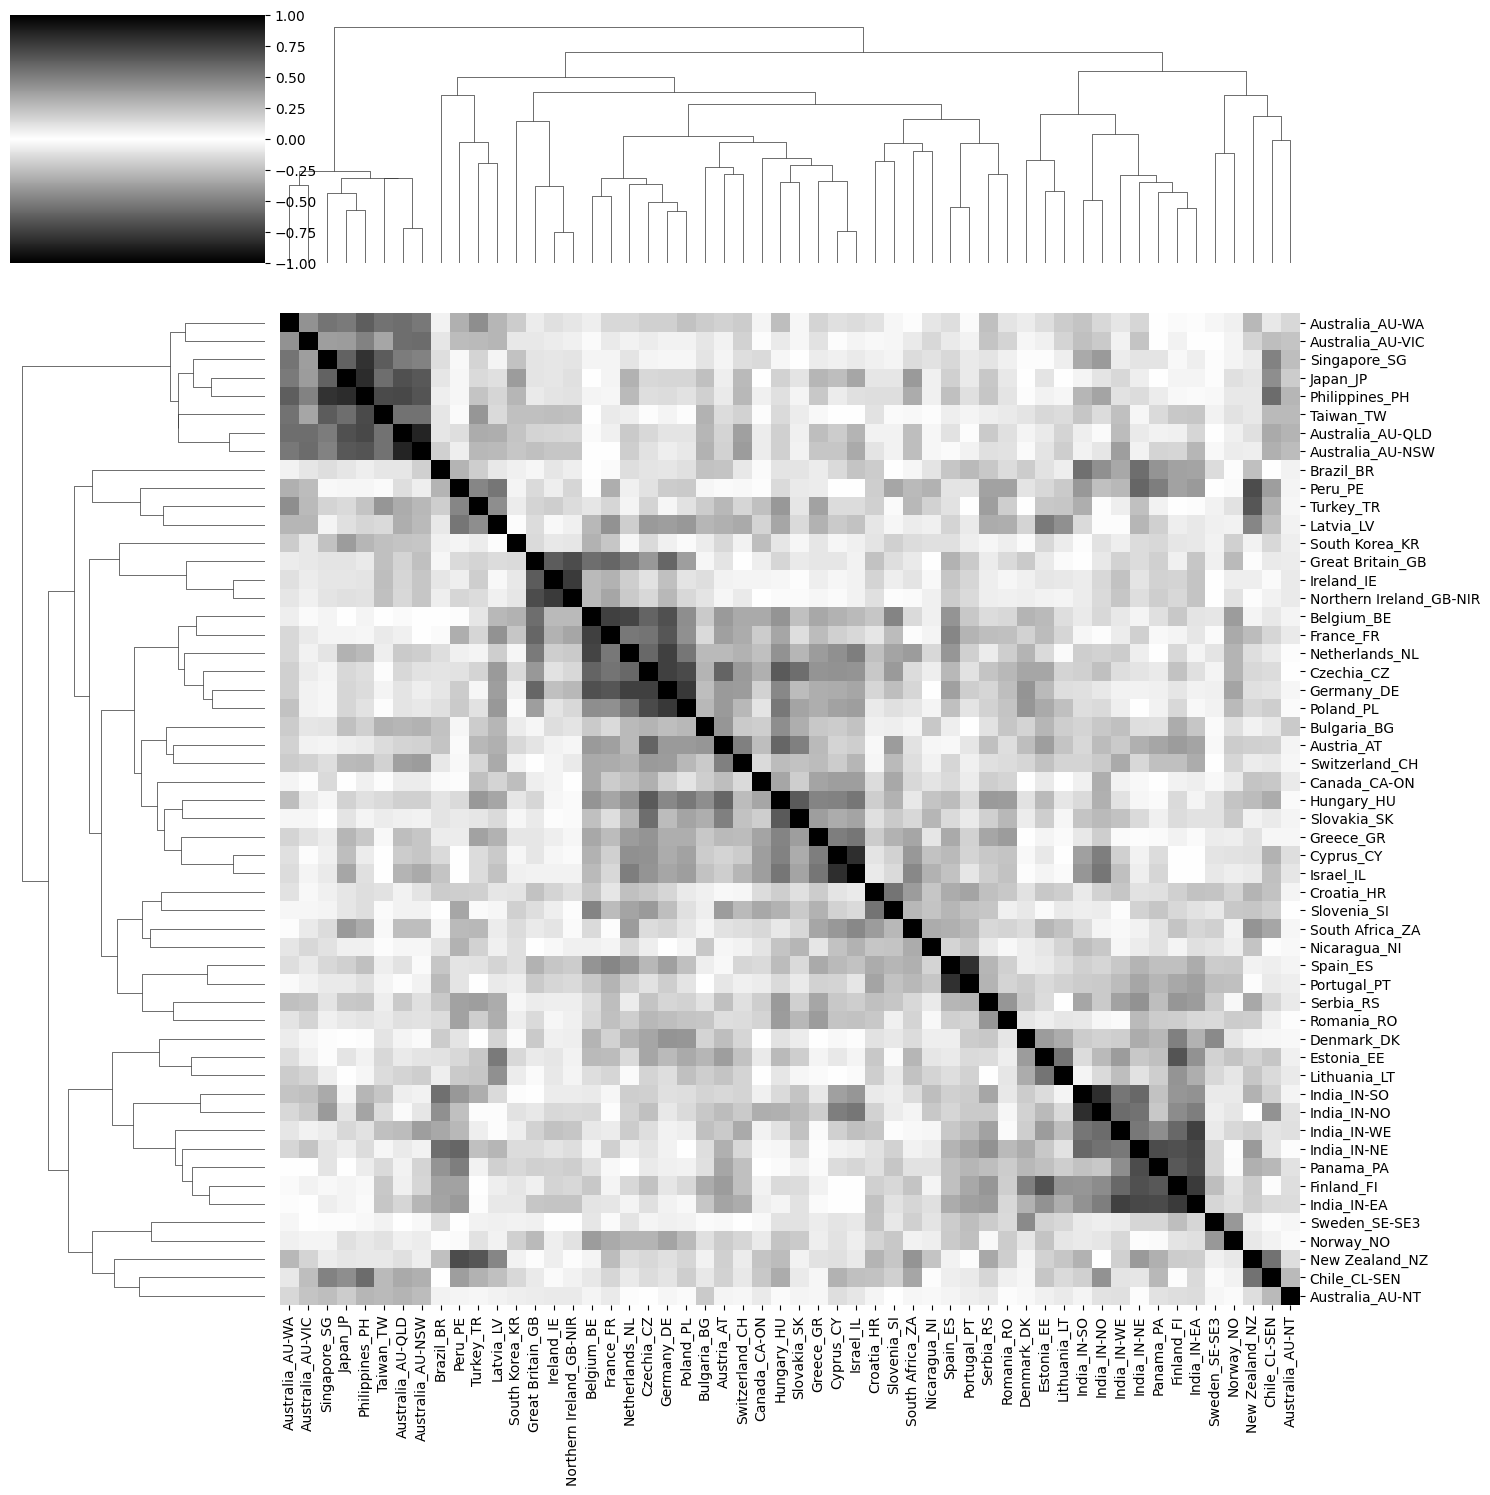

In [5]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics.cluster import contingency_matrix
import numpy as np
countries_list = god_df.columns.to_numpy()

plt.figure()
sns.clustermap(god_df.corr(), cmap=cmap, vmin=-1.0, vmax=1.0,figsize=(15,15))
plt.tight_layout()
plt.show()

# Ranking analysis

In [5]:

# Ranking each row based on the value
val = god_df.rank(ascending=True, method="first", axis=1)

# Converting rank dataframe into tally table with rank as the index
val = pd.concat(
    [
        val[col]
        .value_counts()
        .reset_index()
        .rename(columns={col: "rank", "count": col})
        .set_index("rank")
        for col in val.columns
    ],
    axis=1,
    sort=True,
).fillna(0.0)

In [6]:
# Ordering countries based on the count value for each rank
order_col = []
for row in val.iterrows():
       # Sorting the values only when they are non-zero 
       order_col += row[1][row[1] != 0].drop(index=order_col, errors='ignore').sort_values(ascending=False).index.to_list()

In [7]:
from plotly import express as pe
pe.bar(val, y=val.index, x=order_col, orientation='h')

# Cross correlation analysis

In [8]:
clustering = SpectralClustering(n_clusters=5, affinity='rbf', assign_labels='cluster_qr')
l1 = clustering.fit_predict(god_df.corr())
for _ix in np.unique(l1):
    print(_ix, "->",countries_list[l1 == _ix])

NameError: name 'SpectralClustering' is not defined

In [ ]:
clustering = SpectralClustering(n_clusters=8, affinity='rbf', assign_labels='cluster_qr')
l = clustering.fit_predict(god_df.corr())

for _ix in np.unique(l):
    print(_ix, "->",countries_list[l == _ix])

0 -> ['Chile' 'New Zealand']
1 -> ['Sweden' 'Brazil' 'Estonia' 'Peru' 'Iceland' 'Turkey' 'Norway'
 'Lithuania' 'Latvia']
2 -> ['Finland' 'Denmark' 'India' 'Panama']
3 -> ['Great Britain' 'Ireland' 'Northern Ireland']
4 -> ['Spain' 'Croatia' 'South Africa' 'Slovenia' 'Serbia' 'Portugal'
 'Nicaragua']
5 -> ['Japan' 'Singapore' 'Australia' 'Taiwan' 'South Korea' 'Philippines']
6 -> ['Belgium' 'Germany' 'France' 'Czechia' 'Poland' 'Netherlands']
7 -> ['Austria' 'Hungary' 'Greece' 'Cyprus' 'Costa Rica' 'Canada' 'Bulgaria'
 'Switzerland' 'Slovakia' 'Romania' 'Israel']


/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


In [ ]:
contingency_matrix(l1, l)

array([[ 2,  3,  0,  0,  6,  0,  0,  0],
       [ 0,  0,  0,  3,  0,  0,  0,  0],
       [ 0,  4,  4,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  6,  0,  0],
       [ 0,  2,  0,  0,  1,  0,  6, 11]])

In [ ]:
# Interactive function for heatmap with a sliding window
def interactive_heatmap(start_row=0, window_size=100):
    # Ensure the window size does not exceed the DataFrame length
    end_row = start_row + window_size
    end_row = min(end_row, len(god_df))
    
    # Calculate correlation on the sliding window
    corr_matrix = god_df.iloc[start_row:end_row].corr()

    # Plot heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(corr_matrix, annot=True, cmap=cmap, vmin=-1.0, vmax=1.0)
    plt.title(f'Correlation Matrix from Row {start_row} to {end_row}')
    plt.show()

# Create slider widgets
start_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(god_df) - 1,
    step=1,
    description='Start Row:',
    continuous_update=False
)

window_slider = widgets.IntSlider(
    value=100,
    min=10,
    max=len(god_df),
    step=10,
    description='Window Size:',
    continuous_update=False
)

# Display interactive widget
interact(interactive_heatmap, start_row=start_slider, window_size=window_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Start Row:', max=8759), IntSlid…

<function __main__.interactive_heatmap(start_row=0, window_size=100)>

## Diffent Frequency wise cross correlation value

In [28]:
for month in range(1,13):
    df_god_tmp = god_df.loc[god_df.index.month == month]
    
    correlation_matrix = df_god_tmp.corr()
    
    clustering = SpectralClustering(n_clusters=5, affinity='rbf', assign_labels='cluster_qr')
    l1 = clustering.fit_predict(correlation_matrix)
    
    for _ix in np.unique(l1):
        print(month, "-> ", _ix, "->",correlation_matrix.columns[l1 == _ix].values)

1 ->  0 -> ['Singapore' 'Japan']
1 ->  1 -> ['Spain' 'Hungary' 'South Africa']
1 ->  2 -> ['Germany' 'Austria' 'Brazil' 'Croatia']
1 ->  3 -> ['Sweden' 'Finland' 'Denmark' 'Estonia' 'Peru']
1 ->  4 -> ['Ireland' 'Great Britain' 'France' 'Belgium']
2 ->  0 -> ['Hungary' 'South Africa' 'Peru']
2 ->  1 -> ['Singapore' 'Japan']
2 ->  2 -> ['Ireland' 'Great Britain' 'Croatia']
2 ->  3 -> ['Sweden' 'Finland' 'Brazil' 'Denmark' 'Estonia']
2 ->  4 -> ['Germany' 'Austria' 'France' 'Belgium' 'Spain']
3 ->  0 -> ['Singapore' 'Japan']
3 ->  1 -> ['Sweden' 'Finland' 'Brazil' 'Estonia' 'Peru']
3 ->  2 -> ['Ireland' 'Great Britain' 'France']
3 ->  3 -> ['Austria' 'Hungary' 'South Africa']
3 ->  4 -> ['Germany' 'Belgium' 'Denmark' 'Spain' 'Croatia']
4 ->  0 -> ['Sweden' 'Brazil']
4 ->  1 -> ['Singapore' 'Japan']
4 ->  2 -> ['Austria' 'Hungary' 'South Africa' 'Croatia']
4 ->  3 -> ['Ireland' 'Finland' 'Denmark' 'Estonia' 'Spain' 'Peru']
4 ->  4 -> ['Germany' 'Great Britain' 'France' 'Belgium']
5 ->  0 

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning:

The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning:

The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning:

The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_

In [33]:
for quarter in range(1,5):
    df_god_tmp = god_df.loc[god_df.index.quarter == quarter]
    
    correlation_matrix = df_god_tmp.corr()
    
    clustering = SpectralClustering(n_clusters=5, affinity='rbf', assign_labels='cluster_qr')
    l1 = clustering.fit_predict(correlation_matrix)
    
    for _ix in np.unique(l1):
        print(quarter, "-> ", _ix, "->",correlation_matrix.columns[l1 == _ix].values)

1 ->  0 -> ['Singapore' 'Japan']
1 ->  1 -> ['Austria' 'Spain' 'Hungary' 'South Africa']
1 ->  2 -> ['Brazil' 'Peru' 'Croatia']
1 ->  3 -> ['Sweden' 'Finland' 'Denmark' 'Estonia']
1 ->  4 -> ['Germany' 'Ireland' 'Great Britain' 'France' 'Belgium']
2 ->  0 -> ['Singapore' 'Japan']
2 ->  1 -> ['Brazil' 'Peru']
2 ->  2 -> ['Austria' 'Sweden' 'Finland' 'Denmark']
2 ->  3 -> ['Ireland' 'Great Britain' 'Estonia']
2 ->  4 -> ['Germany' 'France' 'Belgium' 'Spain' 'Hungary' 'South Africa' 'Croatia']
3 ->  0 -> ['Brazil' 'Peru']
3 ->  1 -> ['Singapore' 'Japan']
3 ->  2 -> ['Ireland' 'Sweden' 'Denmark']
3 ->  3 -> ['Finland' 'Estonia']
3 ->  4 -> ['Germany' 'Austria' 'Great Britain' 'France' 'Belgium' 'Spain' 'Hungary'
 'South Africa' 'Croatia']
4 ->  0 -> ['Brazil' 'South Africa' 'Croatia']
4 ->  1 -> ['Singapore' 'Japan']
4 ->  2 -> ['Sweden' 'Finland' 'Denmark' 'Estonia']
4 ->  3 -> ['Austria' 'Spain' 'Hungary' 'Peru']
4 ->  4 -> ['Germany' 'Ireland' 'Great Britain' 'France' 'Belgium']


/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning:

The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning:

The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning:

The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_

In [12]:
def monthly_heatmap(month):
    # Filter the DataFrame for the selected month
    df_god_tmp = god_df.loc[god_df.index.month == month]
    
    correlation_matrix = df_god_tmp.corr()
    
    clustering = SpectralClustering(n_clusters=5, affinity='rbf', assign_labels='cluster_qr')
    l1 = clustering.fit_predict(correlation_matrix)
    
    for _ in np.unique(l1):
        print(month, "-> ", _, "->",correlation_matrix.columns[l1 == _].values)
    
    # Plot the heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(data=df_god_tmp[correlation_matrix.columns[l1.argsort()]].corr(), annot=True, vmin=-1.0, vmax=1.0, cmap=cmap, center=0)
    plt.title(f'Correlation Matrix for Month {month}')
    plt.show()

# Create a slider for month selection
month_slider = IntSlider(value=1, min=1, max=12, step=1, description='Month:', continuous_update=False)

# Use interact to create an interactive widget
interact(monthly_heatmap, month=month_slider)

interactive(children=(IntSlider(value=1, continuous_update=False, description='Month:', max=12, min=1), Output…

<function __main__.monthly_heatmap(month)>

In [179]:
def quarter_heatmap(quarter):
    # Filter the DataFrame for the selected month
    df_god_tmp = god_df.loc[god_df.index.quarter == quarter]
    
    correlation_matrix = df_god_tmp.corr()
    
    clustering = SpectralClustering(n_clusters=5, affinity='rbf', assign_labels='cluster_qr')
    l1 = clustering.fit_predict(correlation_matrix)
    
    for _ in np.unique(l1):
        print(month, "-> ", _, "->",correlation_matrix.columns[l1 == _].values)
    
    # Plot the heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(data=df_god_tmp[correlation_matrix.columns[l1.argsort()]].corr(), annot=True, vmin=-1.0, vmax=1.0, cmap=cmap, center=0)
    plt.title(f'Correlation Matrix for quarter {quarter}')
    plt.show()

# Create a slider for month selection
quarter_slider = IntSlider(value=1, min=1, max=4, step=1, description='quarter:', continuous_update=True)

# Use interact to create an interactive widget
interact(quarter_heatmap, quarter=quarter_slider)

interactive(children=(IntSlider(value=1, description='quarter:', max=4, min=1), Output()), _dom_classes=('widg…

<function __main__.quarter_heatmap(quarter)>

In [78]:
def week_heatmap(week):
    # Filter the DataFrame for the selected month
    df_god_tmp = god_df.loc[god_df.index.isocalendar().week == week]
    
    # Calculate the correlation matrix
    correlation_matrix = df_god_tmp.corr()
    
    # Plot the heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(correlation_matrix, annot=True, vmin=-1.0, vmax=1.0, cmap=cmap, center=0)
    plt.title(f'Correlation Matrix for week {week}')
    plt.show()

# Create a slider for month selection
weekly_slider = IntSlider(value=1, min=1, max=52, step=1, description='Week:', continuous_update=True)

# Use interact to create an interactive widget
interact(week_heatmap, week=weekly_slider)

interactive(children=(IntSlider(value=1, description='Week:', max=52, min=1), Output()), _dom_classes=('widget…

<function __main__.week_heatmap(week)>

# Country analysis with movable avail_mat

In [3]:
import numpy as np

In [7]:
power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
n_rows = 100
all_countries = [BELGIUM, FRANCE, GERMANY, SPAIN, ITALY, GREAT_BRITAIN, IRELAND, DENMARK, SWEDEN, FINLAND, ESTONIA, HUNGARY, CROATIA, URUGUAY, BRAZIL, SINGAPORE, JAPAN, SOUTH_AFRICA]


ghg_god_df = god_df * power * round_duration / 1000

NameError: name 'BELGIUM' is not defined

In [ ]:
from ipywidgets import Button, Box

In [11]:
# Create a list of Checkboxes for each country
checkboxes = [widgets.Checkbox(value=True, description=country) for country in all_countries]

# Create a VBox container for the checkboxes
checkbox_box = Box(children=checkboxes, layout=widgets.Layout(display='flex', flex_flow='row wrap', justify_content='flex-start'))

# Function to plot based on selected countries
def plot_violin(button):
    # Get selected countries from checkboxes
    countries = [checkbox.description for checkbox in checkboxes if checkbox.value]
    
    if not countries:
        print("Please select at least one country!")
        return
    
    try:
        _df = ghg_god_df[countries]
    except KeyError as e:
        print(f"Error: The following countries were not found in the dataset: {e}")
        return
    
    val = list()
    for _ in range(1000):
        _val = list()
        for month in range(1, 13):
            _tmp = _df[_df.index.month == month]  # Correct indexing for month
            if len(_tmp) > 0:
                start_idx = np.random.randint(0, len(_tmp) - 100 + 1)  # Replace 100 with n_rows if needed
                _val.append(np.sum(_tmp.iloc[start_idx:start_idx + 100].values))  # Replace 100 with n_rows if needed
            else:
                _val.append(0)  # If no data for this month, append zero or handle appropriately
        val.append(_val)
    val = np.array(val)
    df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

    # Melt the DataFrame for Seaborn's boxplot format
    df_melted = df.melt(var_name="Month", value_name="Value")

    # Plot the violin plot
    plt.figure(figsize=(12, 6))
    sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
    plt.title(f"Dist tot GHG 100 days with {countries} countries")
    plt.xlabel("Month")
    plt.ylabel("Tot GHG")
    plt.show()

# Create a button widget for "Go"
go_button = Button(description="Go")

# Set the button action to call plot_violin function when clicked
go_button.on_click(plot_violin)

# Display the widgets
display(checkbox_box, go_button)

NameError: name 'all_countries' is not defined

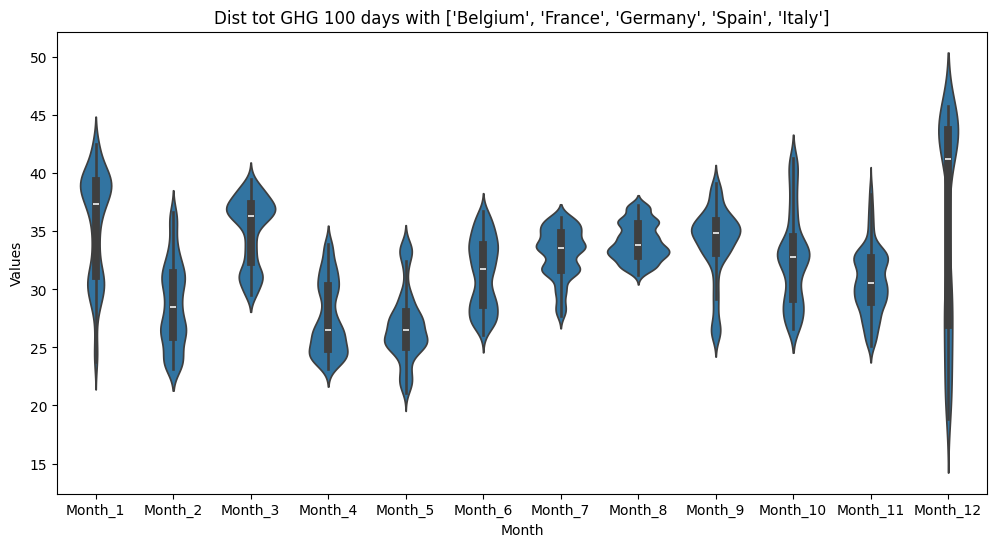

In [20]:
countries = [BELGIUM, FRANCE, GERMANY, SPAIN, ITALY]
val = list()
_df = ghg_god_df[countries]
for _ix in range(1000):
    _val = list()
    for month in range(1,13):
        val = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(val) - n_rows + 1)
        _val.append(np.sum(val.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()

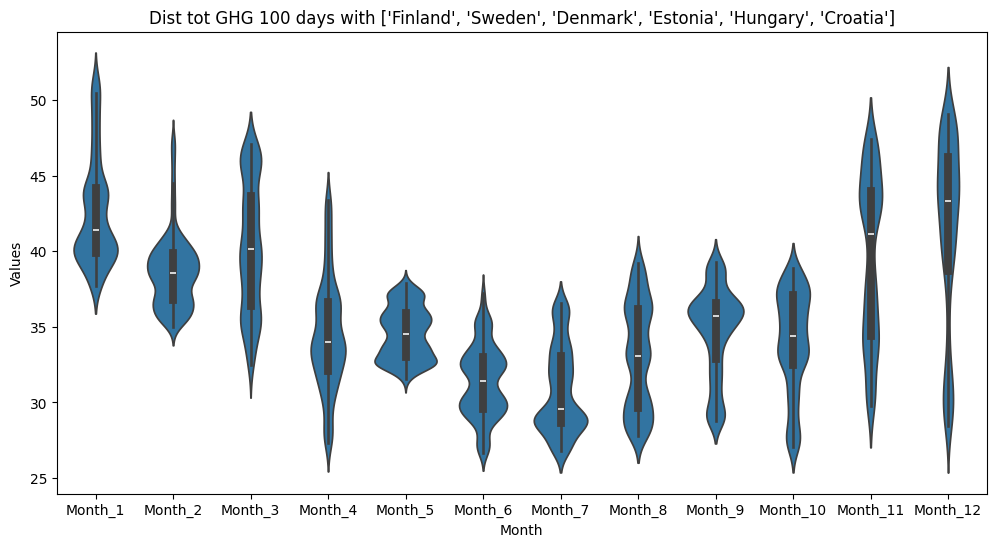

In [21]:
countries = [FINLAND, SWEDEN, DENMARK, ESTONIA, HUNGARY, CROATIA]
val = list()
_df = ghg_god_df[countries]
for _ix in range(1000):
    _val = list()
    for month in range(1,13):
        val = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(val) - n_rows + 1)
        _val.append(np.sum(val.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()

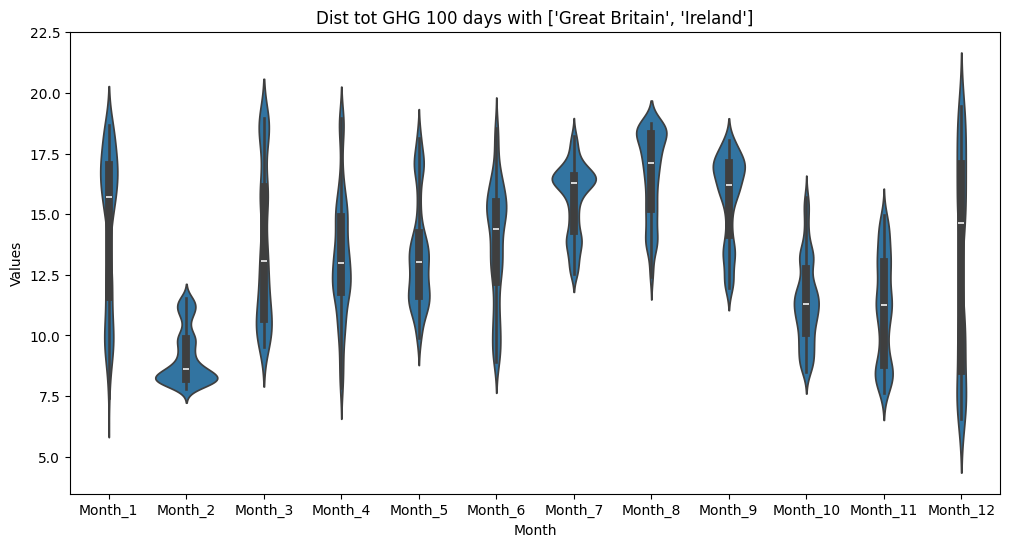

In [23]:
countries = [GREAT_BRITAIN, IRELAND]
val = list()
_df = ghg_god_df[countries]
for _ix in range(1000):
    _val = list()
    for month in range(1,13):
        val = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(val) - n_rows + 1)
        _val.append(np.sum(val.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()

## Analysis between n clients on average and n clients chosen dynamically

In [ ]:
import random
from datetime import timedelta

In [8]:
power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round


ghg_god_df = god_df * power * round_duration / 1000

# Check the code below with synthetic data [1,0] and [1.1,0] as two countries alternative

In [11]:
import random
from datetime import timedelta

power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
n_rows = 100


ghg_god_df = god_df * power * round_duration / 1000

In [7]:
# _check_tmp = pd.DataFrame({
#     'cnt1': np.hstack([np.array([0.0, 1.0]) for _ in range(50)]),
#     'cnt2': np.hstack([np.array([1.1, 0.0]) for _ in range(50)])
# })

# _avg_ci = _check_tmp.mean().sort_values()
# _sorted_arr = np.sort(_check_tmp.values, axis=1)

# # Iterating over number of countries considered; the list is appended
# print([
#     (1 - np.sum(_sorted_arr[:, :k])/np.sum(_check_tmp[_avg_ci.index[:k].to_list()].values))
#     for k in range(1, _avg_ci.__len__() + 1)
# ])

In [7]:
def get_results(ghg_god_df, list_countries, window=100, no_samples=100):
    _res = []
    _df = ghg_god_df[list_countries]
    tot_list_hours = _df.index.to_list()
    for _ in range(no_samples):
        
        # Choosing random start time
        start_time = random.choice(tot_list_hours[: -(window-1)])
        # Truncating the dataframe
        _trunc_arr = _df.truncate(before=start_time, after=start_time+timedelta(hours=window-1))
        
        # Sorting the array across time axis
        _sorted_arr = np.sort(_trunc_arr.values, axis=1)
        
        _avg_ci = _trunc_arr.mean().sort_values()
        # Iterating over number of countries considered; the list is appended
        _res.append([
            (1 - np.sum(_sorted_arr[:, :k])/np.sum(_trunc_arr[_avg_ci.index[:k].to_list()].values))
            for k in range(1, _avg_ci.__len__() + 1)
        ])
    return np.array(_res)

In [17]:
def fetch_plt(data):
    
    df = pd.DataFrame(data, columns=list(range(1, data.shape[1] + 1)))

    # Set up the boxplot
    plt.figure(figsize=(20, 10))  # Increased figure size for more space
    sns.boxplot(data=df, showmeans=False, color="seagreen")

    # Add title and labels
    plt.title("")
    plt.xlabel("Number of clients considered", fontsize=14, labelpad=20)  # Added padding
    plt.ylabel("Percentage difference", fontsize=14, labelpad=20)  # Added padding

    # Rotate x-axis ticks by 90 degrees for better readability
    plt.xticks(rotation=90, fontsize=12, ha="right")  # Adjusted font size and alignment
    plt.yticks(fontsize=12)

    # Remove the top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Adjust padding between elements
    plt.tight_layout(pad=3.0)  # Increase padding to avoid cramping
    plt.show()

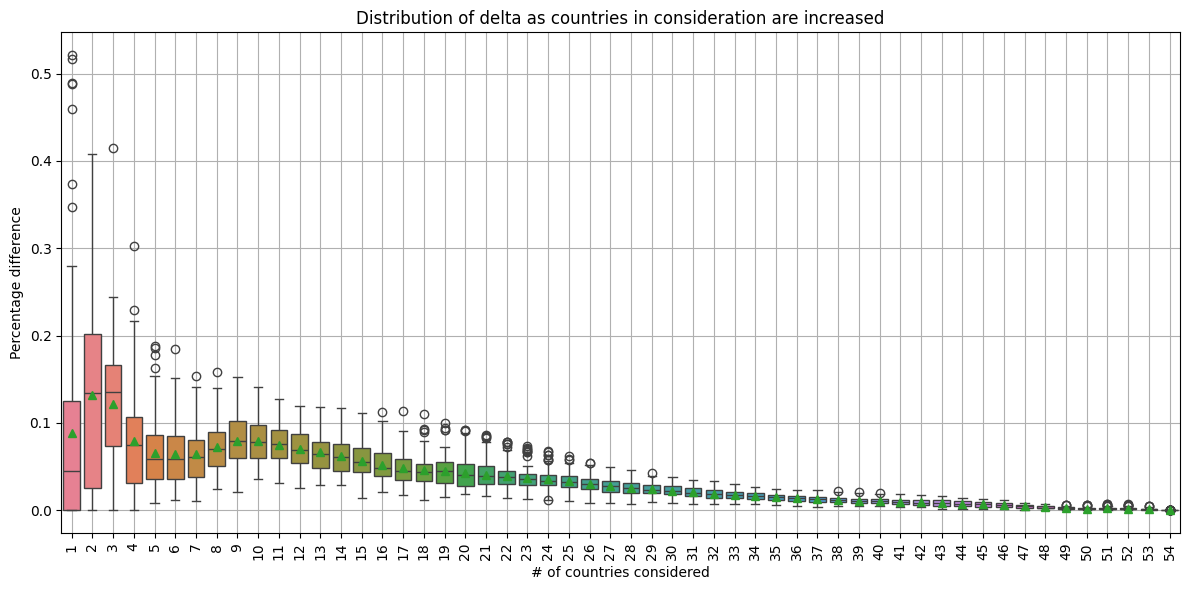

In [17]:
fetch_plt(get_results(ghg_god_df= ghg_god_df, list_countries=ghg_god_df.columns))

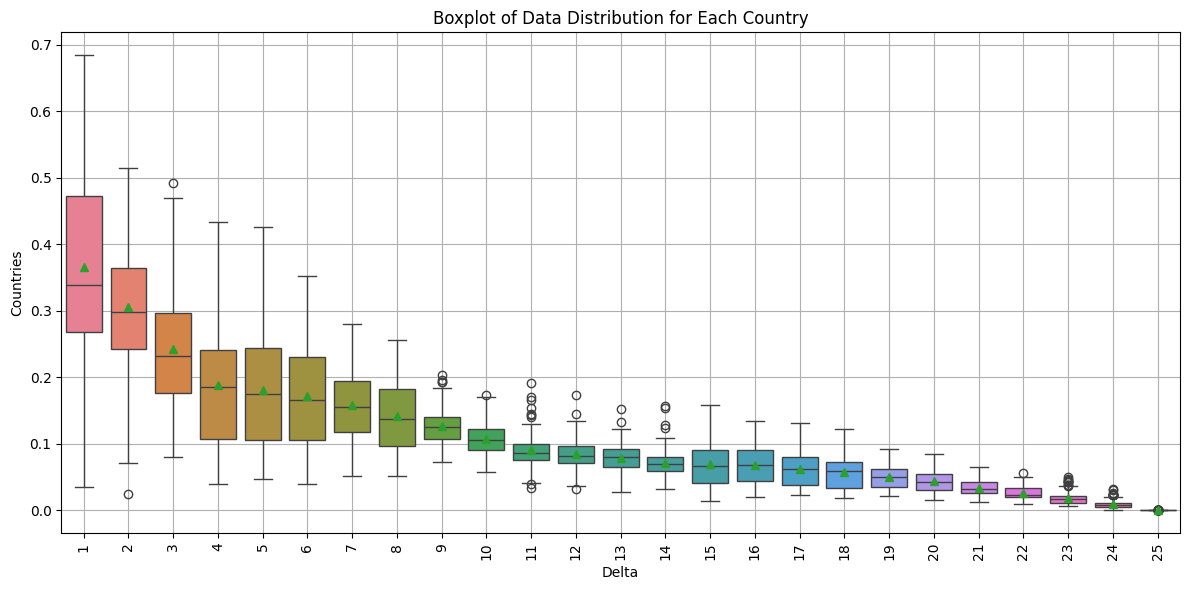

In [49]:
fetch_plt(get_results(ghg_god_df= ghg_god_df, list_countries=['Germany_DE', 'Ireland_IE', 'Austria_AT', 'Estonia_EE', 'Spain_ES',
       'Croatia_HR', 'Hungary_HU', 'Japan_JP', 'Singapore_SG', 'India_IN-NE',
       'Greece_GR', 'Chile_CL-SEN', 'Australia_AU-WA', 'Australia_AU-NT',
       'Turkey_TR', 'Taiwan_TW', 'South Korea_KR', 'Slovenia_SI',
       'Slovakia_SK', 'Romania_RO', 'Panama_PA', 'Northern Ireland_GB-NIR',
       'Netherlands_NL', 'Lithuania_LT', 'Latvia_LV']))

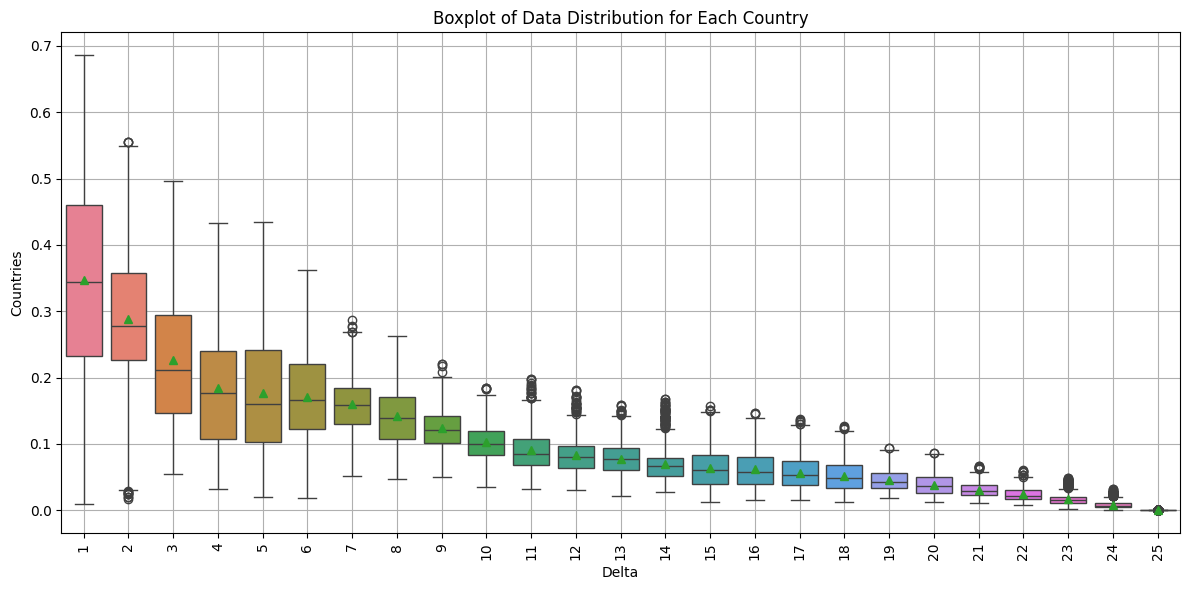

In [50]:
fetch_plt(get_results(ghg_god_df= ghg_god_df, list_countries=['Germany_DE', 'Ireland_IE', 'Austria_AT', 'Estonia_EE', 'Spain_ES',
       'Croatia_HR', 'Hungary_HU', 'Japan_JP', 'Singapore_SG', 'India_IN-NE',
       'Greece_GR', 'Chile_CL-SEN', 'Australia_AU-WA', 'Australia_AU-NT',
       'Turkey_TR', 'Taiwan_TW', 'South Korea_KR', 'Slovenia_SI',
       'Slovakia_SK', 'Romania_RO', 'Panama_PA', 'Northern Ireland_GB-NIR',
       'Netherlands_NL', 'Lithuania_LT', 'Latvia_LV'], window=100, no_samples=1000))

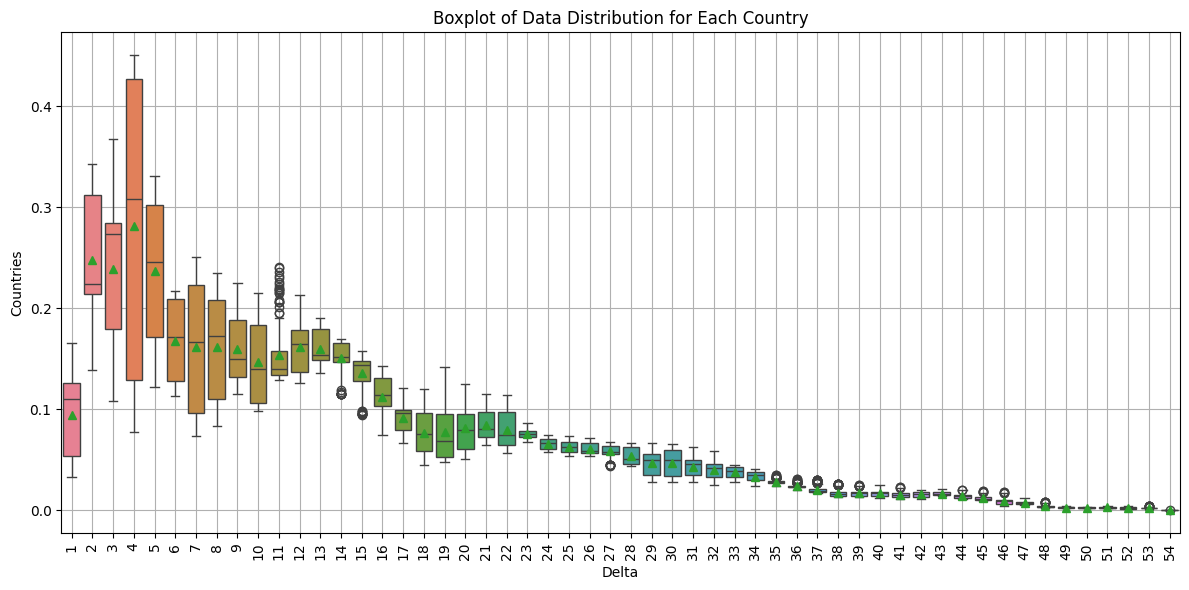

In [51]:
fetch_plt(get_results(ghg_god_df= ghg_god_df, list_countries=ghg_god_df.columns, window=2500, no_samples=150))

# Choosing 100 steps out of N hours

In [8]:
def get_results_mod(ghg_god_df, list_countries, max_window=100, no_samples=100):
    _res = []
    _df = ghg_god_df[list_countries]
    tot_list_hours = _df.index.to_list()
    
    for _ in range(no_samples):

        # Choosing random start time
        start_time = random.choice(tot_list_hours[: -(max_window - 1)])
        # Truncating the dataframe
        _trunc_arr = _df.truncate(
            before=start_time, after=start_time + timedelta(hours=max_window - 1)
        )
        _avg_ci = _trunc_arr.mean().sort_values()

        _tmp = np.argsort(_trunc_arr.values, axis=0)
        _masked_array = np.zeros_like(_trunc_arr, dtype=int)
        rows_to_mask = _tmp[:100, :]  # Top 100 row indices for each column
        _masked_array[rows_to_mask, np.arange(_trunc_arr.shape[1])] = 1

        values = _trunc_arr.values[rows_to_mask, np.arange(_trunc_arr.shape[1])]
        ranked_intelli = np.argsort(np.sum(values, axis=0))

        # Iterating over number of countries considered; the list is appended
        _res.append(
            [
                1
                - np.sum(values[:, ranked_intelli[:k]])
                / np.sum(
                    np.sort(_trunc_arr[_avg_ci.index[:k].to_list()].values, axis=0)[
                        :100, :
                    ]
                )
                for k in range(1, 55)
            ]
        )
    return np.array(_res)

In [9]:
def get_results_mod1(ghg_god_df, list_countries, max_window=100, no_samples=100):
    _res = []
    _df = ghg_god_df[list_countries]
    tot_list_hours = _df.index.to_list()
    max_time_delta = timedelta(hours=max_window - 1)
    _avg_ci = ghg_god_df.mean().sort_values()
    for _ in range(no_samples):

        # Choosing random start time
        start_time = random.choice(tot_list_hours[: -(max_window - 1)])
        # Truncating the dataframe
        _trunc_arr = _df.truncate(before=start_time, after=start_time + max_time_delta)
        

        # Sort indices along each column in descending order
        sorted_indices = np.argsort(_trunc_arr.values, axis=0)

        # Select the top k indices for each column
        top_k_indices = sorted_indices[:100, :]

        # Create a mask for the top k elements
        mask = np.zeros_like(_trunc_arr.values, dtype=bool)
        for col in range(_trunc_arr.shape[1]):
            mask[top_k_indices[:, col], col] = True

        # Retain the original order of elements
        result = np.where(
            mask, _trunc_arr.values, 0.0
        )  # Replace non-top-k elements with NaN
        ranked_intelli = np.argsort(np.sum(result, axis=0))

        _res.append(
            [
                1
                - np.sum(result[:, ranked_intelli[:k]])
                / (np.sum(_avg_ci[:k].values) * 100)
                for k in range(1, 1 + len(list_countries))
            ]
        )
    return np.array(_res)

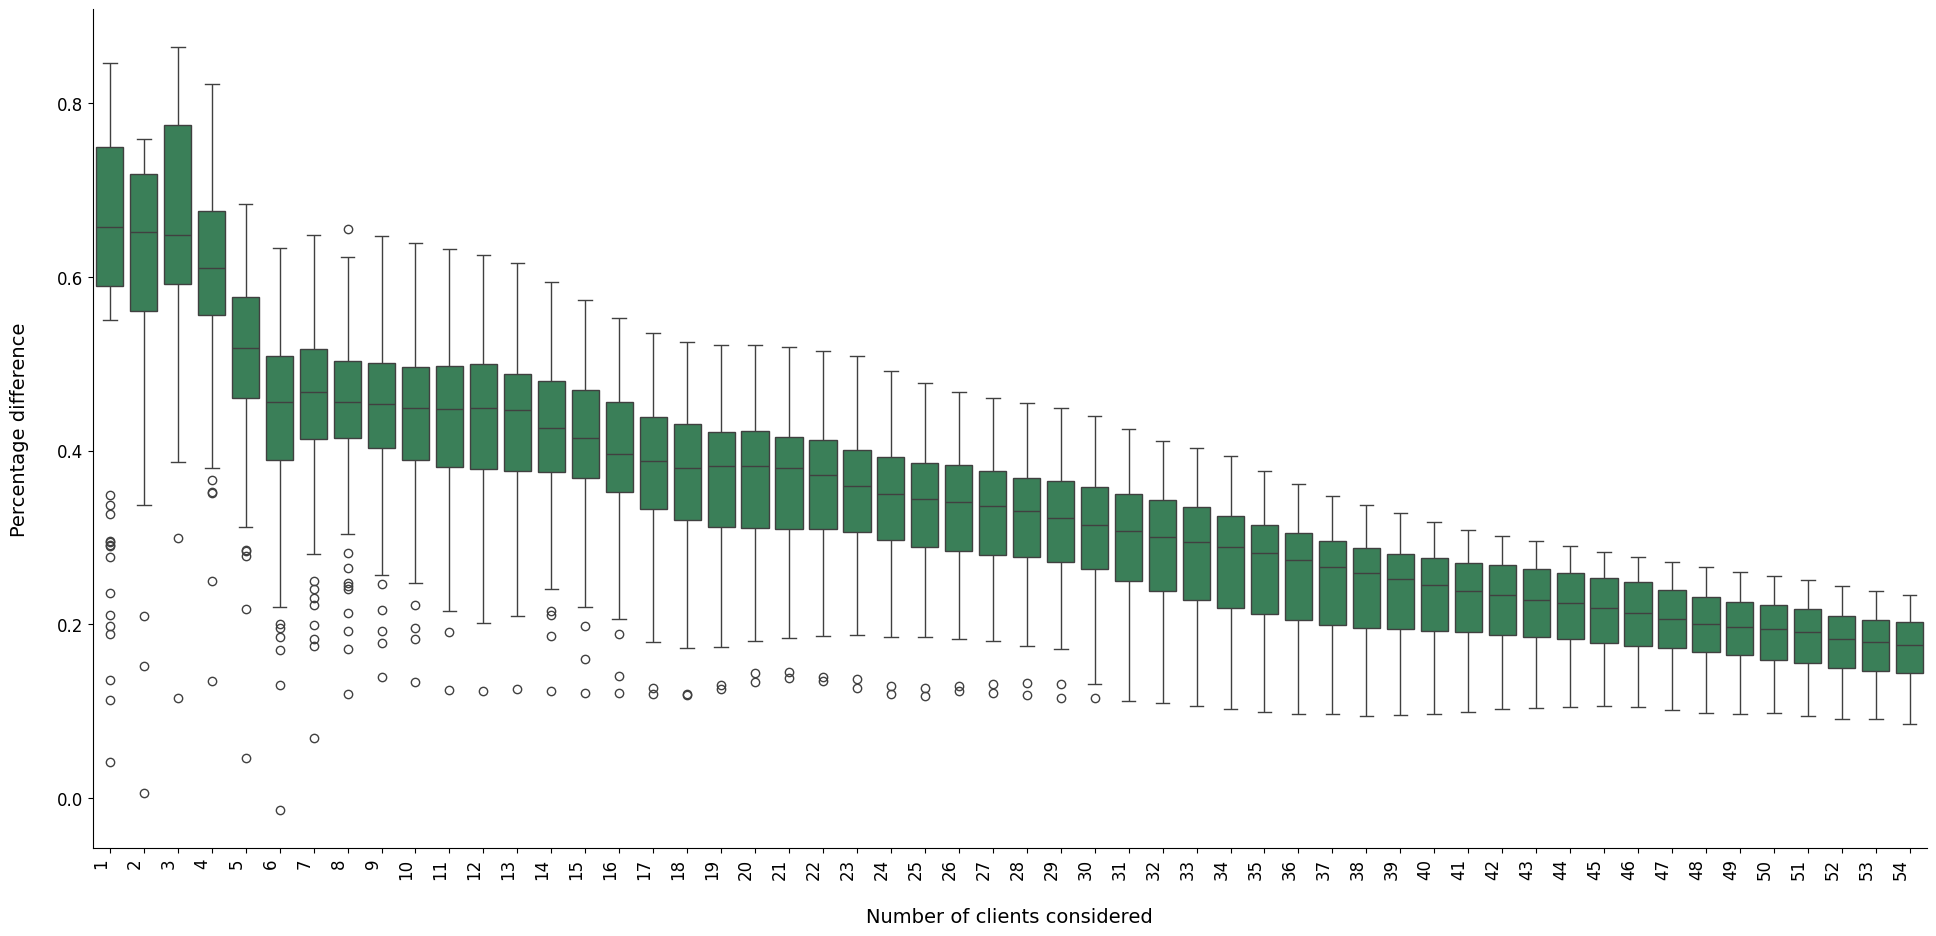

In [18]:
fetch_plt(get_results_mod1(ghg_god_df= ghg_god_df, list_countries=ghg_god_df.columns, max_window=336))

In [11]:
def get_results_mod2(ghg_god_df, list_countries, max_window=100, no_samples=100):
    _res = []
    _df = ghg_god_df[list_countries]
    tot_list_hours = _df.index.to_list()
    max_time_delta = timedelta(hours=max_window - 1)
    
    for _ in range(no_samples):

        # Choosing random start time
        start_time = random.choice(tot_list_hours[: -(max_window - 1)])
        # Truncating the dataframe
        _trunc_arr = _df.truncate(before=start_time, after=start_time + max_time_delta)
        _avg_ci = _trunc_arr.mean().sort_values()

        # Sort indices along each column in descending order
        sorted_indices = np.argsort(_trunc_arr.values, axis=0)

        # Select the top k indices for each column
        top_k_indices = sorted_indices[:100, :]

        # Create a mask for the top k elements
        mask = np.zeros_like(_trunc_arr.values, dtype=bool)
        for col in range(_trunc_arr.shape[1]):
            mask[top_k_indices[:, col], col] = True

        # Retain the original order of elements
        result = np.where(
            mask, _trunc_arr.values, 0.0
        )  # Replace non-top-k elements with NaN\
            
        ranked_intelli = np.argsort(np.sum(result, axis=0))

        _res.append(
            [
                1 - np.sum(result[:, ranked_intelli[:k]]) / (np.sum(_avg_ci[:k].values) * 100)
                for k in range(1, 1 + len(list_countries))
            ]
        )
    return np.array(_res)

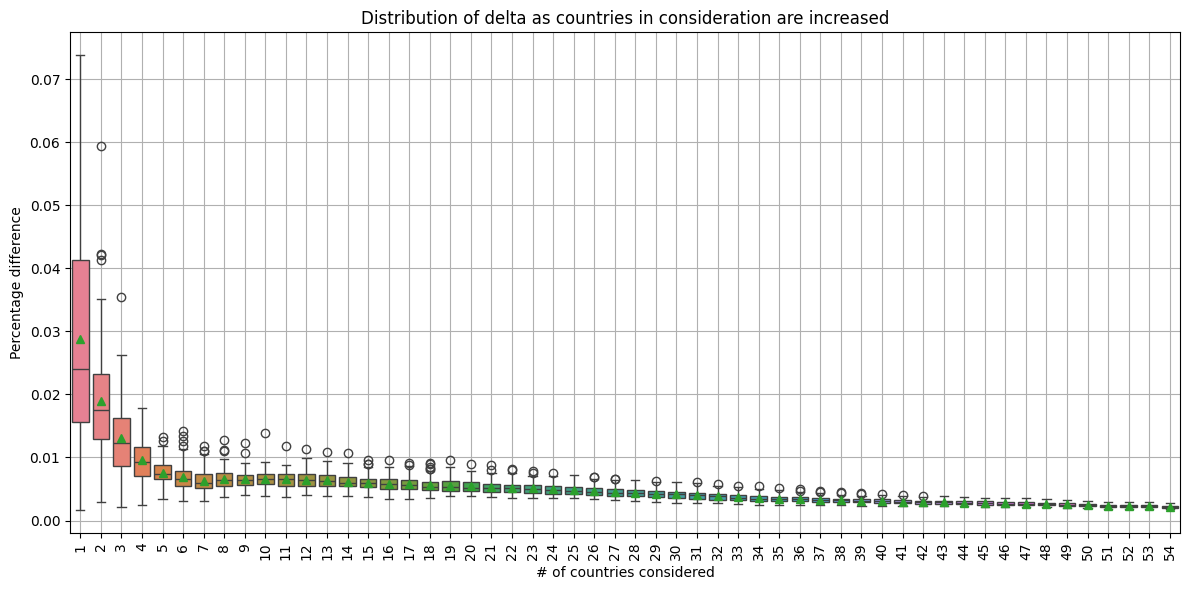

In [14]:
fetch_plt(get_results_mod2(ghg_god_df= ghg_god_df, list_countries=ghg_god_df.columns, max_window=101))

/run/netsop/u/home-sam/home/draviarp/Documents/FedStale/venv/lib64/python3.12/site-packages/sklearn/cluster/_spectral.py:702: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


['Great Britain_GB' 'Ireland_IE' 'Brazil_BR' 'Spain_ES' 'Croatia_HR'
 'South Korea_KR' 'Portugal_PT' 'Northern Ireland_GB-NIR']


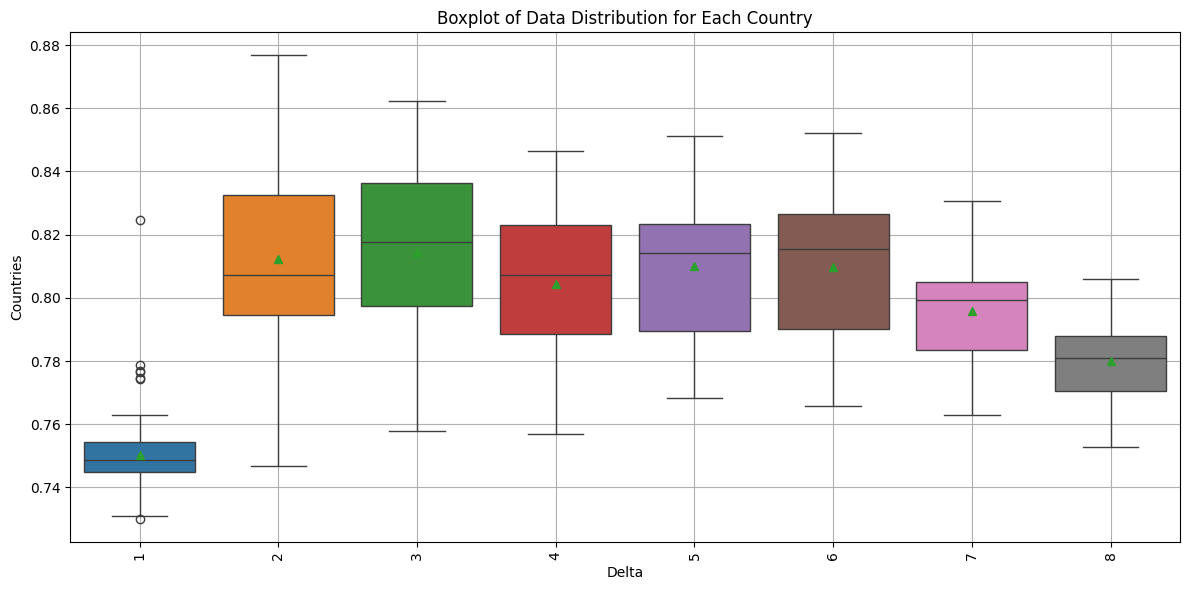

['Finland_FI' 'Sweden_SE-SE3' 'Denmark_DK' 'Estonia_EE' 'India_IN-WE'
 'India_IN-SO' 'India_IN-NO' 'India_IN-NE' 'India_IN-EA' 'Chile_CL-SEN'
 'Australia_AU-NT' 'Panama_PA' 'Norway_NO' 'New Zealand_NZ' 'Lithuania_LT']


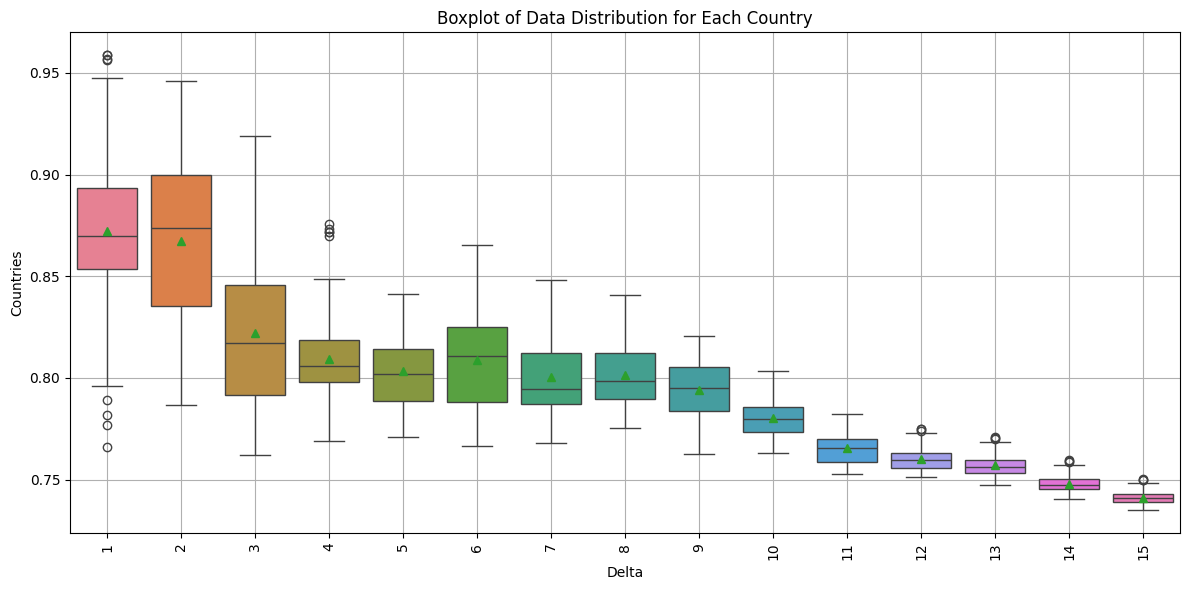

['Japan_JP' 'Singapore_SG' 'Australia_AU-WA' 'Australia_AU-VIC'
 'Australia_AU-QLD' 'Australia_AU-NSW' 'Taiwan_TW' 'Philippines_PH']


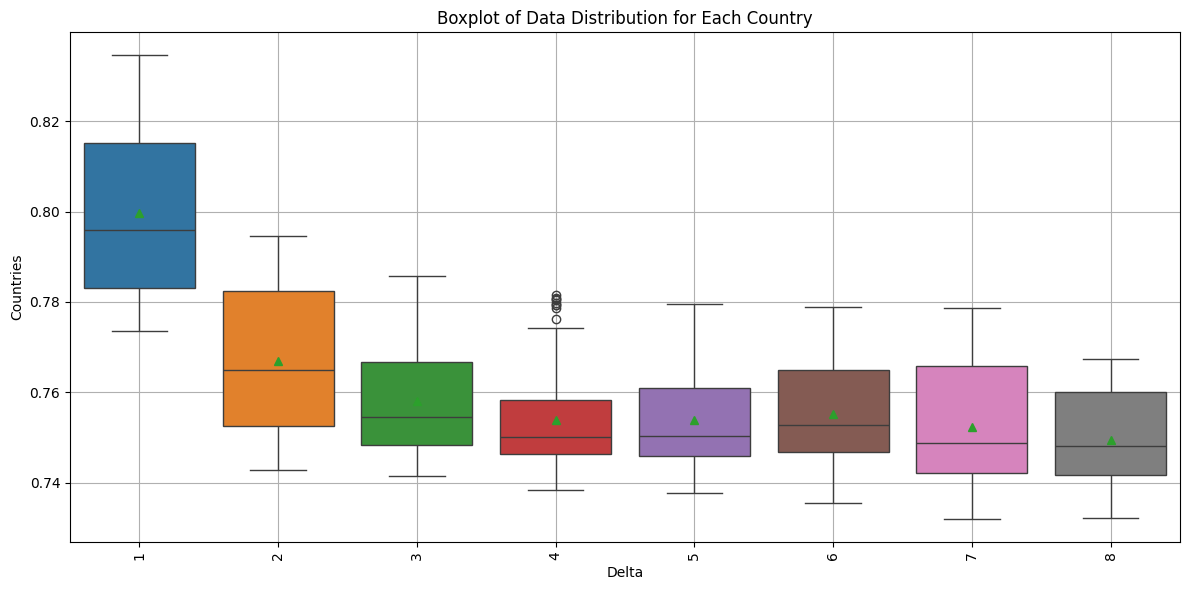

['Belgium_BE' 'Germany_DE' 'France_FR' 'Austria_AT' 'Hungary_HU' 'Peru_PE'
 'South Africa_ZA' 'Greece_GR' 'Czechia_CZ' 'Cyprus_CY' 'Canada_CA-ON'
 'Bulgaria_BG' 'Turkey_TR' 'Switzerland_CH' 'Slovenia_SI' 'Slovakia_SK'
 'Serbia_RS' 'Romania_RO' 'Poland_PL' 'Nicaragua_NI' 'Netherlands_NL'
 'Latvia_LV' 'Israel_IL']


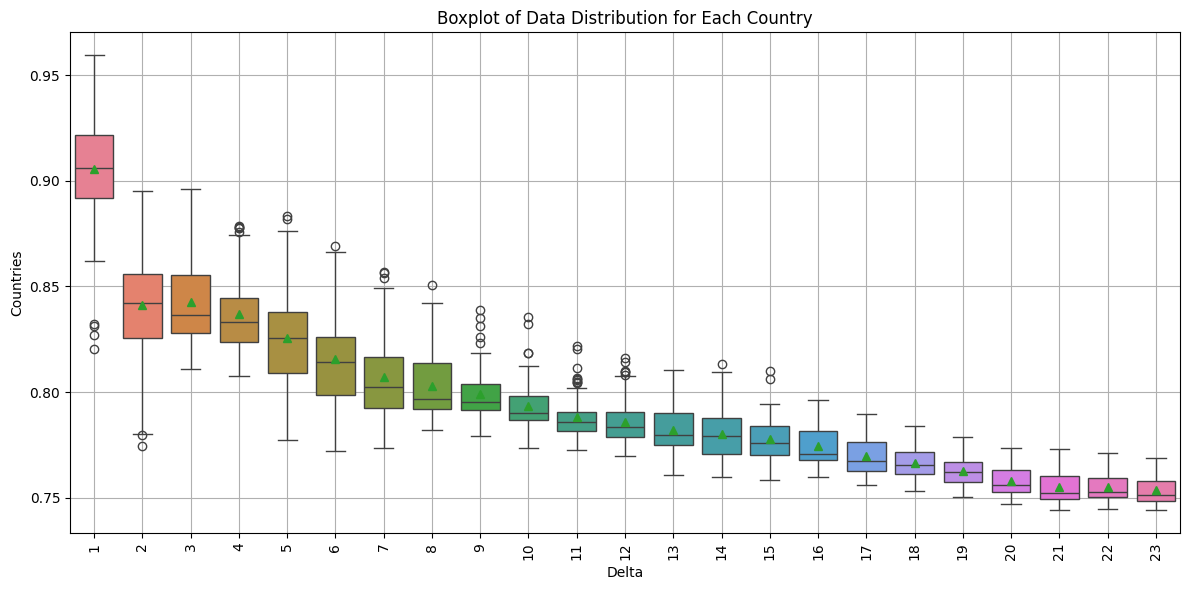

In [26]:
clustering = SpectralClustering(n_clusters=4, affinity='rbf', assign_labels='cluster_qr')
l1 = clustering.fit_predict(ghg_god_df.corr())

for _ix in np.unique(l1):
    _li_cntrs = ghg_god_df.columns[l1 == _ix].values
    print(_li_cntrs)
    fetch_plt(get_results_mod2(ghg_god_df,_li_cntrs,max_window=336))

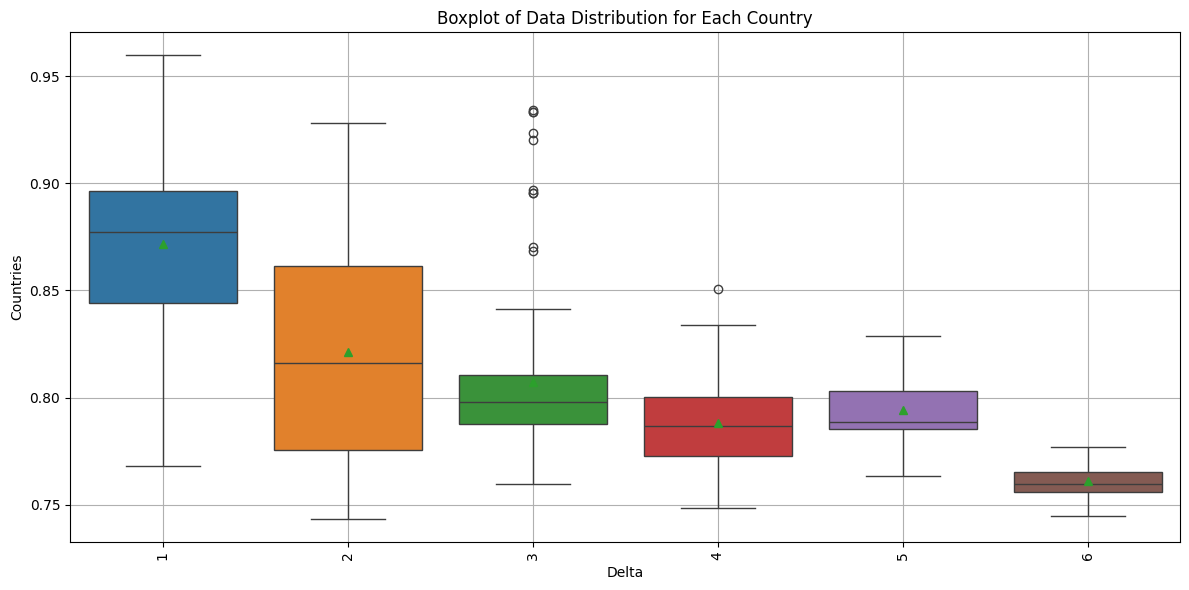

In [73]:
fetch_plt(get_results_mod2(ghg_god_df,["Singapore_SG", "Netherlands_NL", "Portugal_PT", "Finland_FI", "New Zealand_NZ", "Sweden_SE-SE3"],max_window=336))

In [1]:
def fetch_plt(data):
    
    df = pd.DataFrame(data, columns=list(range(1,data.shape[1]+1)))

    # Set up the boxplot
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, showmeans=True)

    # Add title and labels
    plt.title("Boxplot of Data Distribution for Each Country")
    plt.xlabel("Delta")
    plt.ylabel("Countries")
    plt.grid(True)
    # Rotate x-axis ticks by 90 degrees for better readability
    plt.xticks(rotation=90)

    # Show the plot
    plt.tight_layout()
    plt.show()

In [9]:
from collections import defaultdict

def _country_slack_heatmap_alt(ghg_god_df, list_countries, no_samples=100):
    _df = ghg_god_df[list_countries].to_numpy()  # Convert to NumPy for faster slicing
    tot_list_hours = ghg_god_df.index.to_list()
    final_res = {}

    for max_window in range(101, 336, 10):
        _res = defaultdict(list)  # Faster than dict initialization
        max_time_window = max_window - 1

        valid_start_idx = len(tot_list_hours) - max_time_window

        for _ in range(no_samples):
            start_idx = random.randint(0, valid_start_idx - 1)
            truncated_arr = _df[start_idx : start_idx + max_window]

            base_ci = truncated_arr[:100].sum(axis=0)  # Compute once

            # Compute percentage for all countries using NumPy
            sorted_vals = np.sort(truncated_arr, axis=0)[:100]
            perc = 1 - np.sum(sorted_vals, axis=0) / base_ci

            for i, cnt in enumerate(list_countries):
                _res[cnt].append(perc[i])

        # Store means directly
        final_res[max_window - 100] = {cnt: np.mean(vals) for cnt, vals in _res.items()}

    return pd.DataFrame.from_dict(final_res, orient="index")

In [12]:
tmp = _country_slack_heatmap_alt(ghg_god_df=ghg_god_df, list_countries=ghg_god_df.columns)

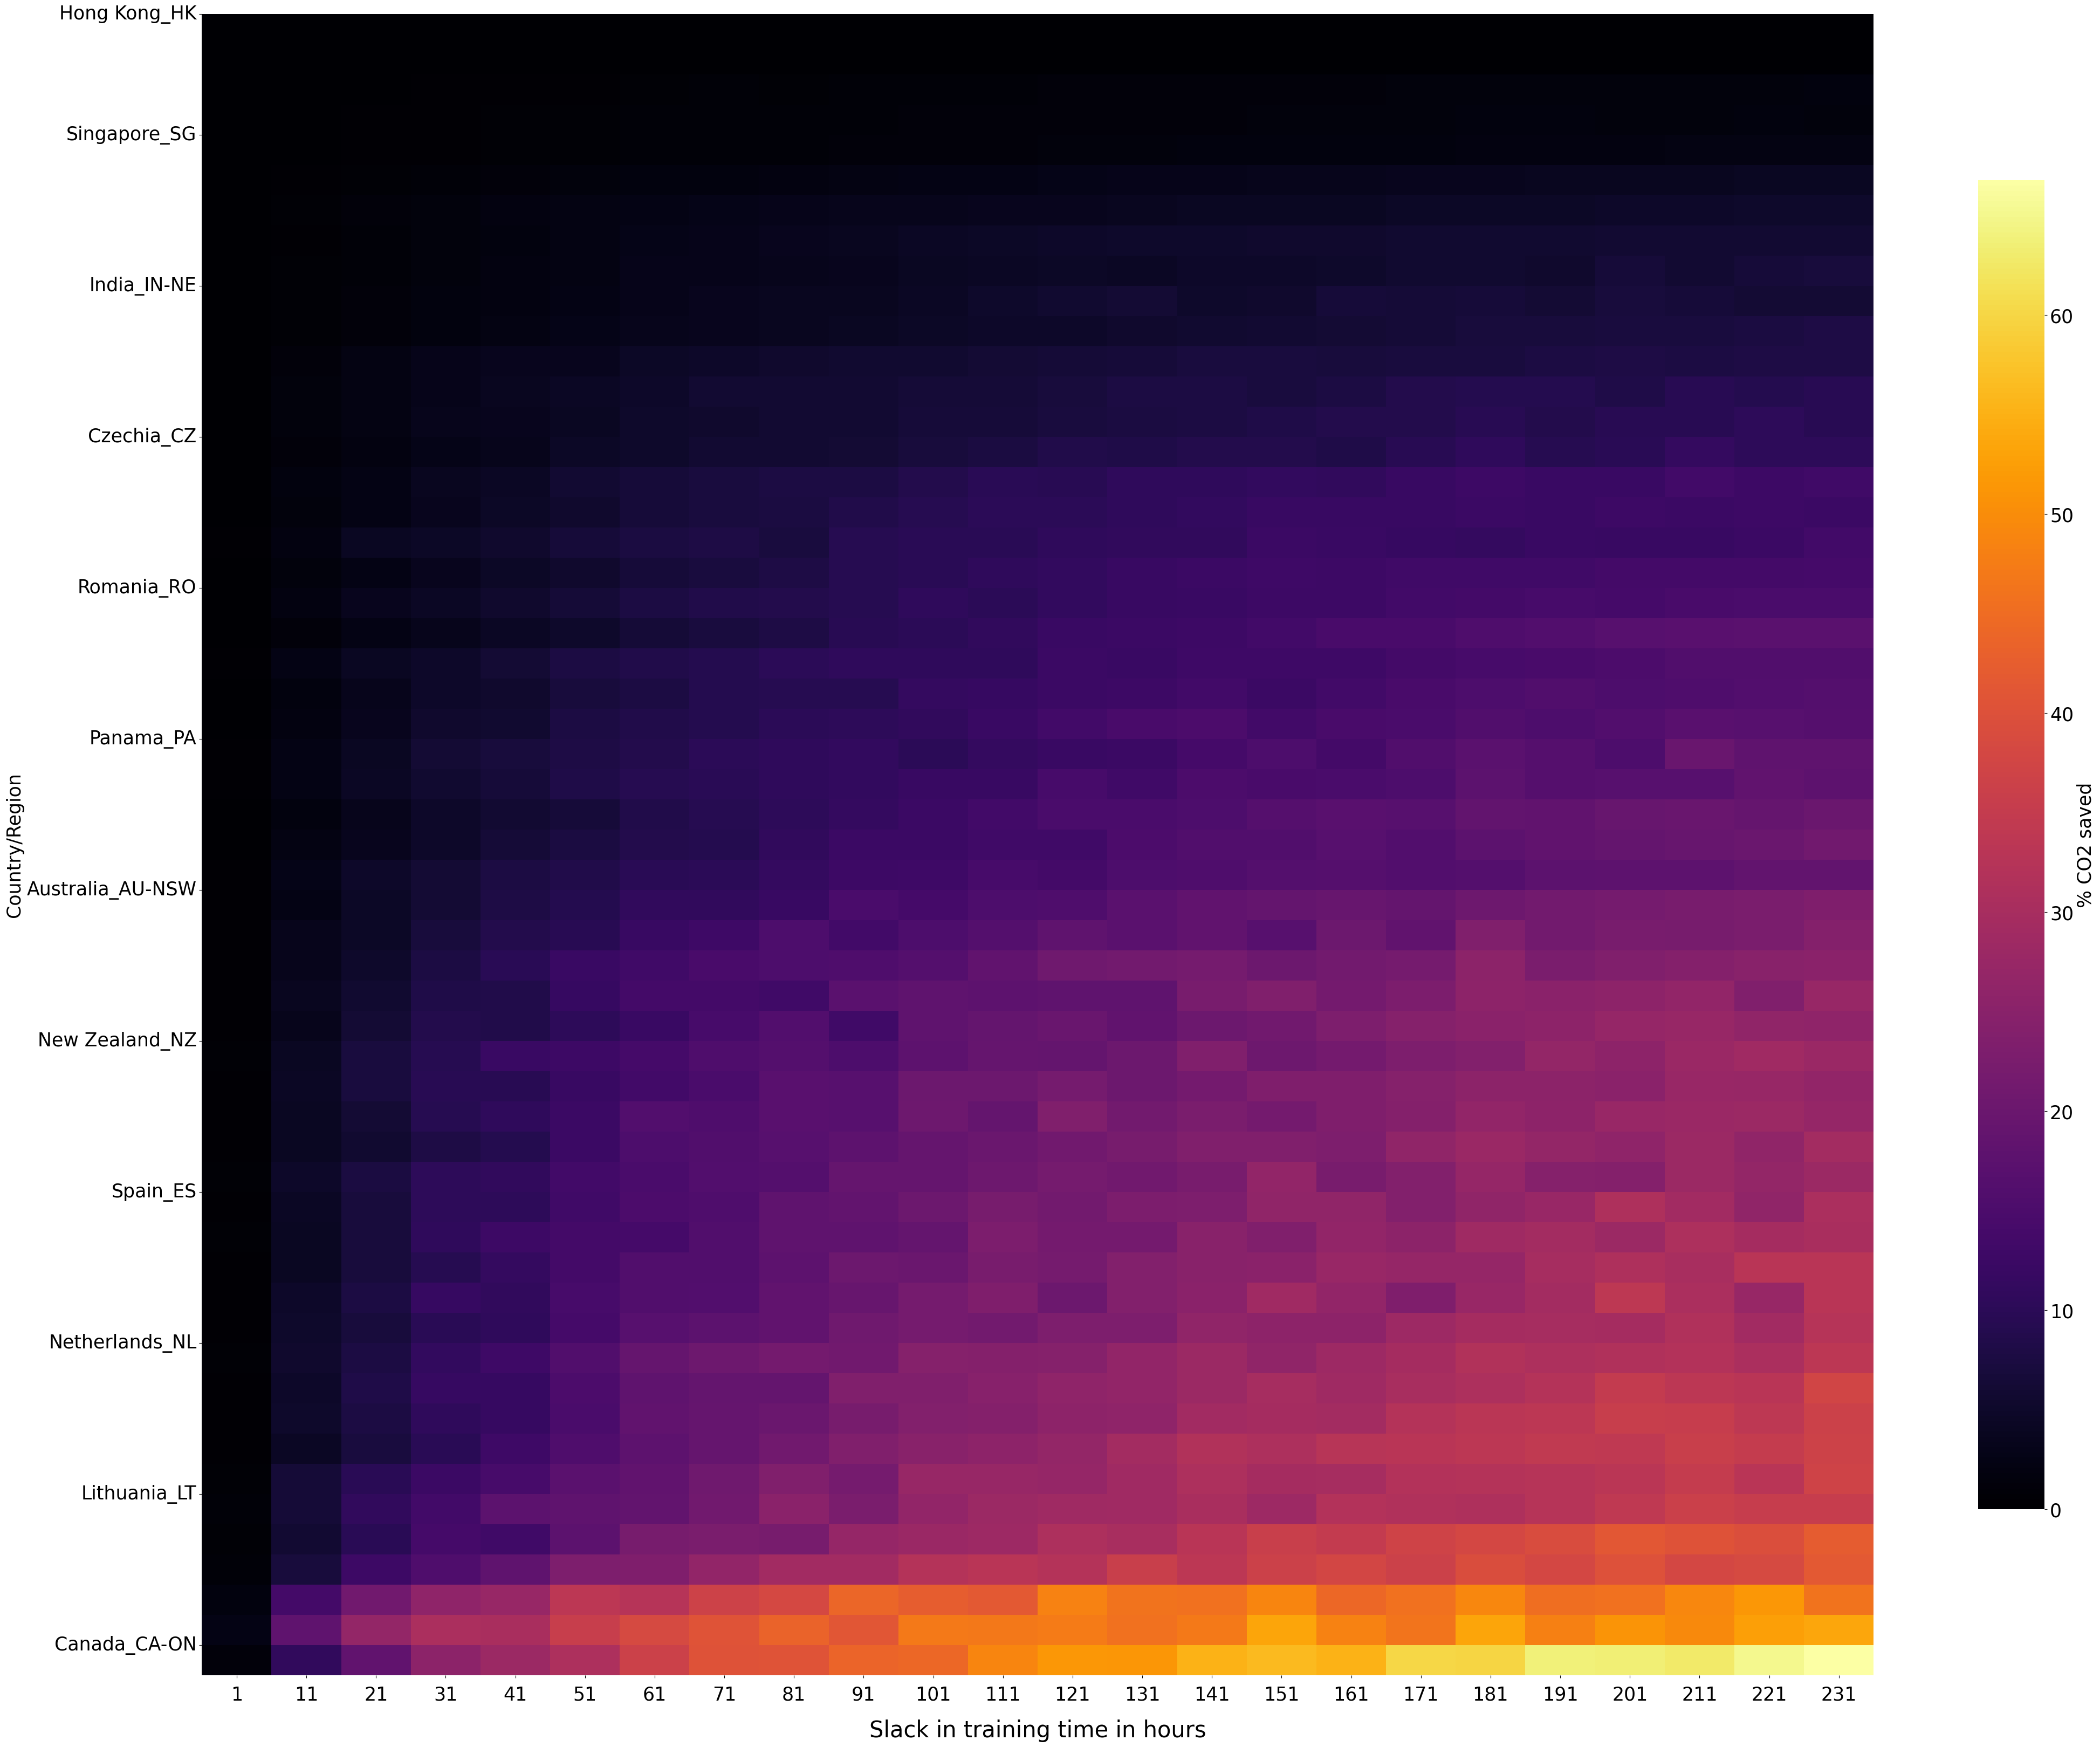

In [54]:
ranked_countries = tmp.mean().sort_values().index.values
fig, ax = plt.subplots(figsize=(50, 40)) 

scaled_data = tmp[ranked_countries].T * 100
sns.heatmap(scaled_data, cmap='inferno', ax=ax, cbar_kws={'label': '% CO2 saved', 'shrink': 0.8}, 
            vmin=scaled_data.min().min(), vmax=scaled_data.max().max())

# Increase spacing for x-axis label and ticks
ax.set_xlabel("Slack in training time in hours", fontsize=30, labelpad=20)  # Label padding
ax.tick_params(axis='x', labelsize=25, pad=10)  # Tick padding

ax.set_ylabel("Country/Region", fontsize=25)
ax.tick_params(axis='y', labelsize=25)

# Display only a few y-axis labels
num_labels = 12  # Change this number as needed
yticks = np.linspace(0, len(ranked_countries)-1, num_labels, dtype=int)  # Select indices
ax.set_yticks(yticks)
ax.set_yticklabels([ranked_countries[i] for i in yticks], ha='right', fontsize=25)

# Increase color bar label and tick size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(25)  
cbar.ax.tick_params(labelsize=25)  

plt.savefig("../../slack_analysis.png")
plt.show()

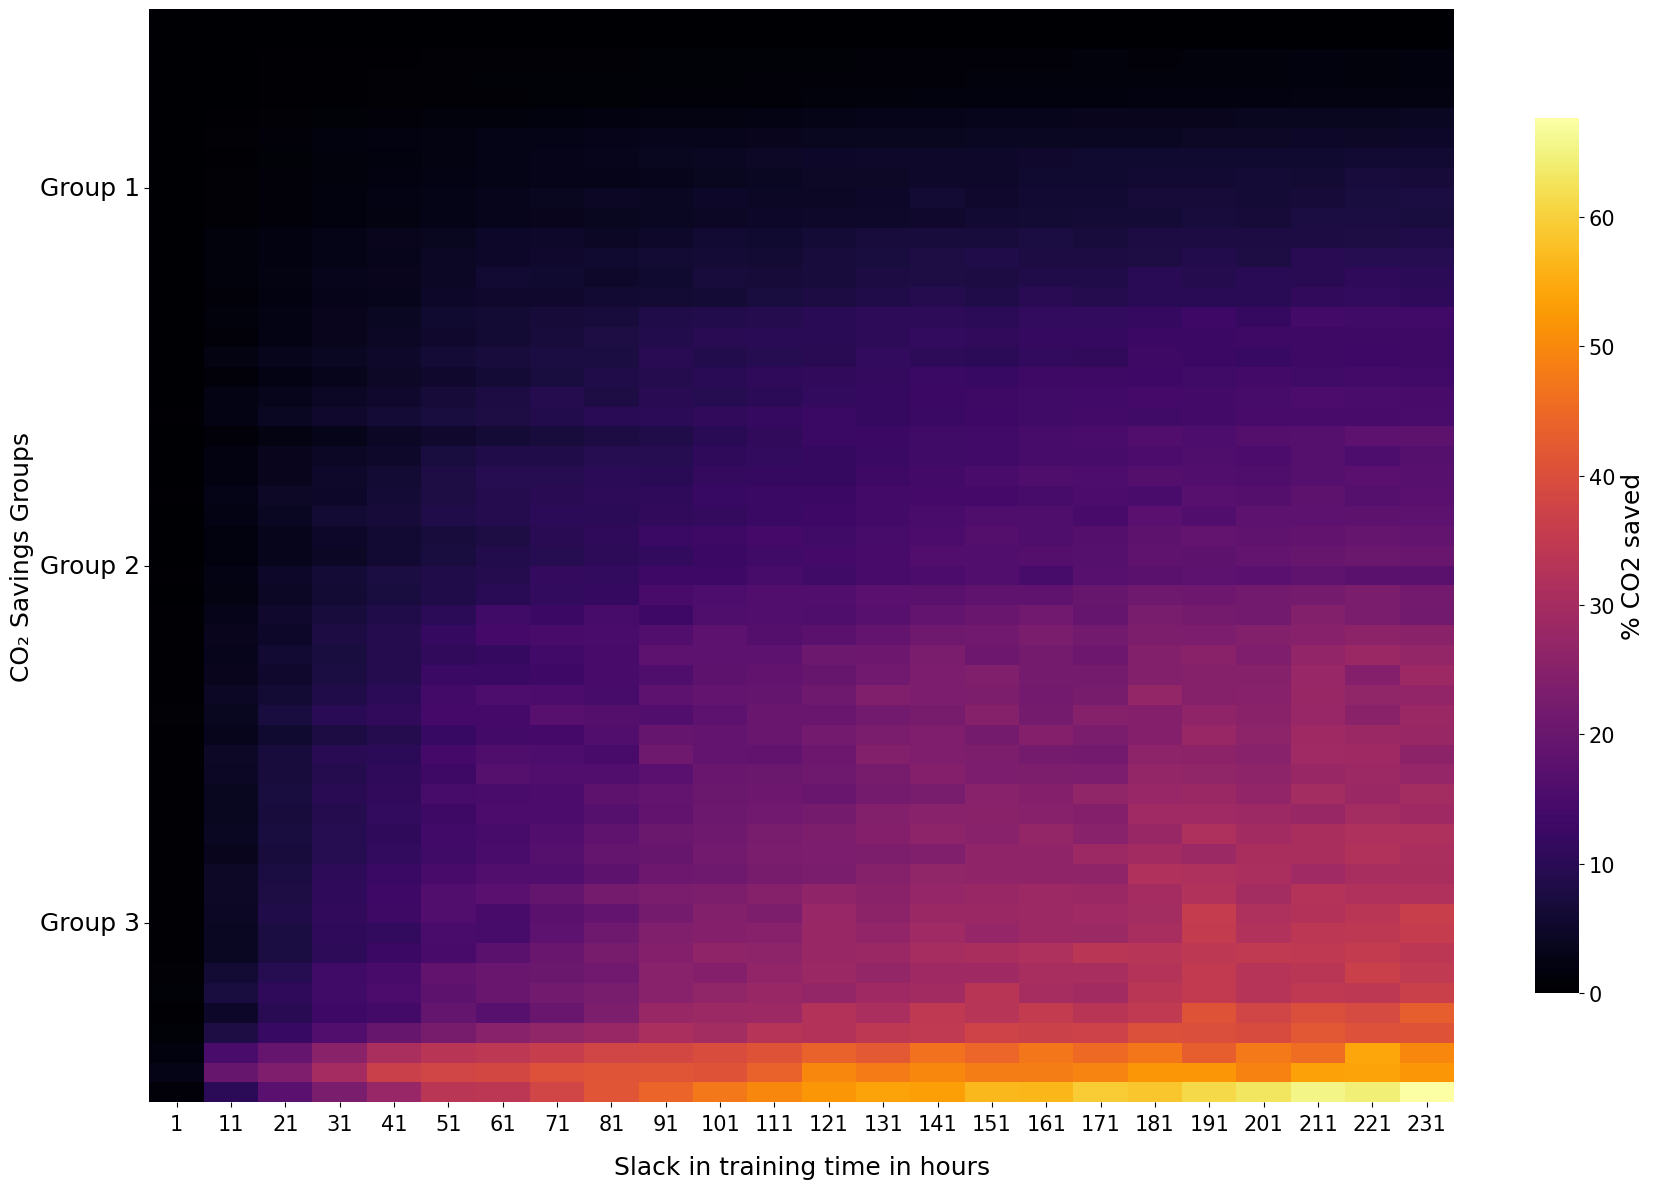

In [14]:
# Rank countries based on CO2 savings
ranked_countries = tmp.mean().sort_values().index.values

# Define number of groups
num_groups = 3  # High, Medium, Low CO2 savings
group_labels = ["Group 1", "Group 2", "Group 3"]

# Split into 3 equal-sized groups
group_sizes = np.array_split(ranked_countries, num_groups)

# Create mapping of y-ticks to group names
y_tick_positions = [len(group) // 2 + sum(len(g) for g in group_sizes[:i]) for i, group in enumerate(group_sizes)]
y_tick_labels = group_labels

# Generate heatmap
fig, ax = plt.subplots(figsize=(18, 12))

scaled_data = tmp[ranked_countries].T * 100
sns.heatmap(scaled_data, cmap='inferno', ax=ax, cbar_kws={'label': '% CO2 saved', 'shrink': 0.8}, 
            vmin=scaled_data.min().min(), vmax=scaled_data.max().max())

ax.set_xlabel("Slack in training time in hours", fontsize=18, labelpad=15)
ax.set_ylabel("CO₂ Savings Groups", fontsize=18)
ax.tick_params(axis='x', labelsize=15, pad=5)

# Set y-axis labels to grouped names
ax.set_yticks(y_tick_positions)
ax.set_yticklabels(y_tick_labels, fontsize=18)

# Increase color bar label and tick size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(18)  
cbar.ax.tick_params(labelsize=15)  

plt.tight_layout()
plt.savefig("../../slack_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [24]:
def _country_slack_heatmap(ghg_god_df, list_countries, no_samples=100):
    _df = ghg_god_df[list_countries]
    tot_list_hours = _df.index.to_list()
    final_res = dict()
    for max_window in range(100, 336):
        _res = {cnt: list() for cnt in list_countries}
        max_time_window = timedelta(hours=max_window - 1)
        for _ in range(no_samples):
            # Choosing random start time
            start_time = random.choice(tot_list_hours[: -(max_window - 1)])
            # Truncating the data frame
            _trunc_arr = _df.truncate(
                before=start_time, after=start_time + max_time_window
            )
            avg_ci = _trunc_arr.mean()
            # Sorting for each countries along time axis
            for col in _trunc_arr.columns:
                perc = 1 - np.sum(np.sort(_trunc_arr[col].values, axis=0)[:100])/(100*avg_ci[col])
                _res[col].append(perc)
        final_res[max_window - 100] = {col: np.mean(_res[col]) for col in _res.keys()}
    return pd.DataFrame.from_dict(final_res, orient="index")

tmp = _country_slack_heatmap(ghg_god_df=ghg_god_df, list_countries=ghg_god_df.columns)

In [17]:
def _country_slack_heatmap(ghg_god_df, list_countries, no_samples=100):
    _df = ghg_god_df[list_countries]
    tot_list_hours = _df.index.to_list()
    final_res = dict()
    for max_window in range(100, 336, 10):
        _res = {cnt: list() for cnt in list_countries}
        max_time_window = timedelta(hours=max_window - 1)
        for _ in range(no_samples):
            # Choosing random start time
            start_time = random.choice(tot_list_hours[: -(max_window - 1)])
            # Truncating the data frame
            _trunc_arr = _df.truncate(
                before=start_time, after=start_time + max_time_window
            )
            avg_ci = _trunc_arr.mean()
            # Sorting for each countries along time axis
            for col in _trunc_arr.columns:
                perc = 1 - np.sum(np.sort(_trunc_arr[col].values, axis=0)[:100])/(100*avg_ci[col])
                _res[col].append(perc)
        final_res[max_window - 100] = {col: np.mean(_res[col]) for col in _res.keys()}
    return pd.DataFrame.from_dict(final_res, orient="index")

tmp = _country_slack_heatmap(ghg_god_df=ghg_god_df, list_countries=ghg_god_df.columns)

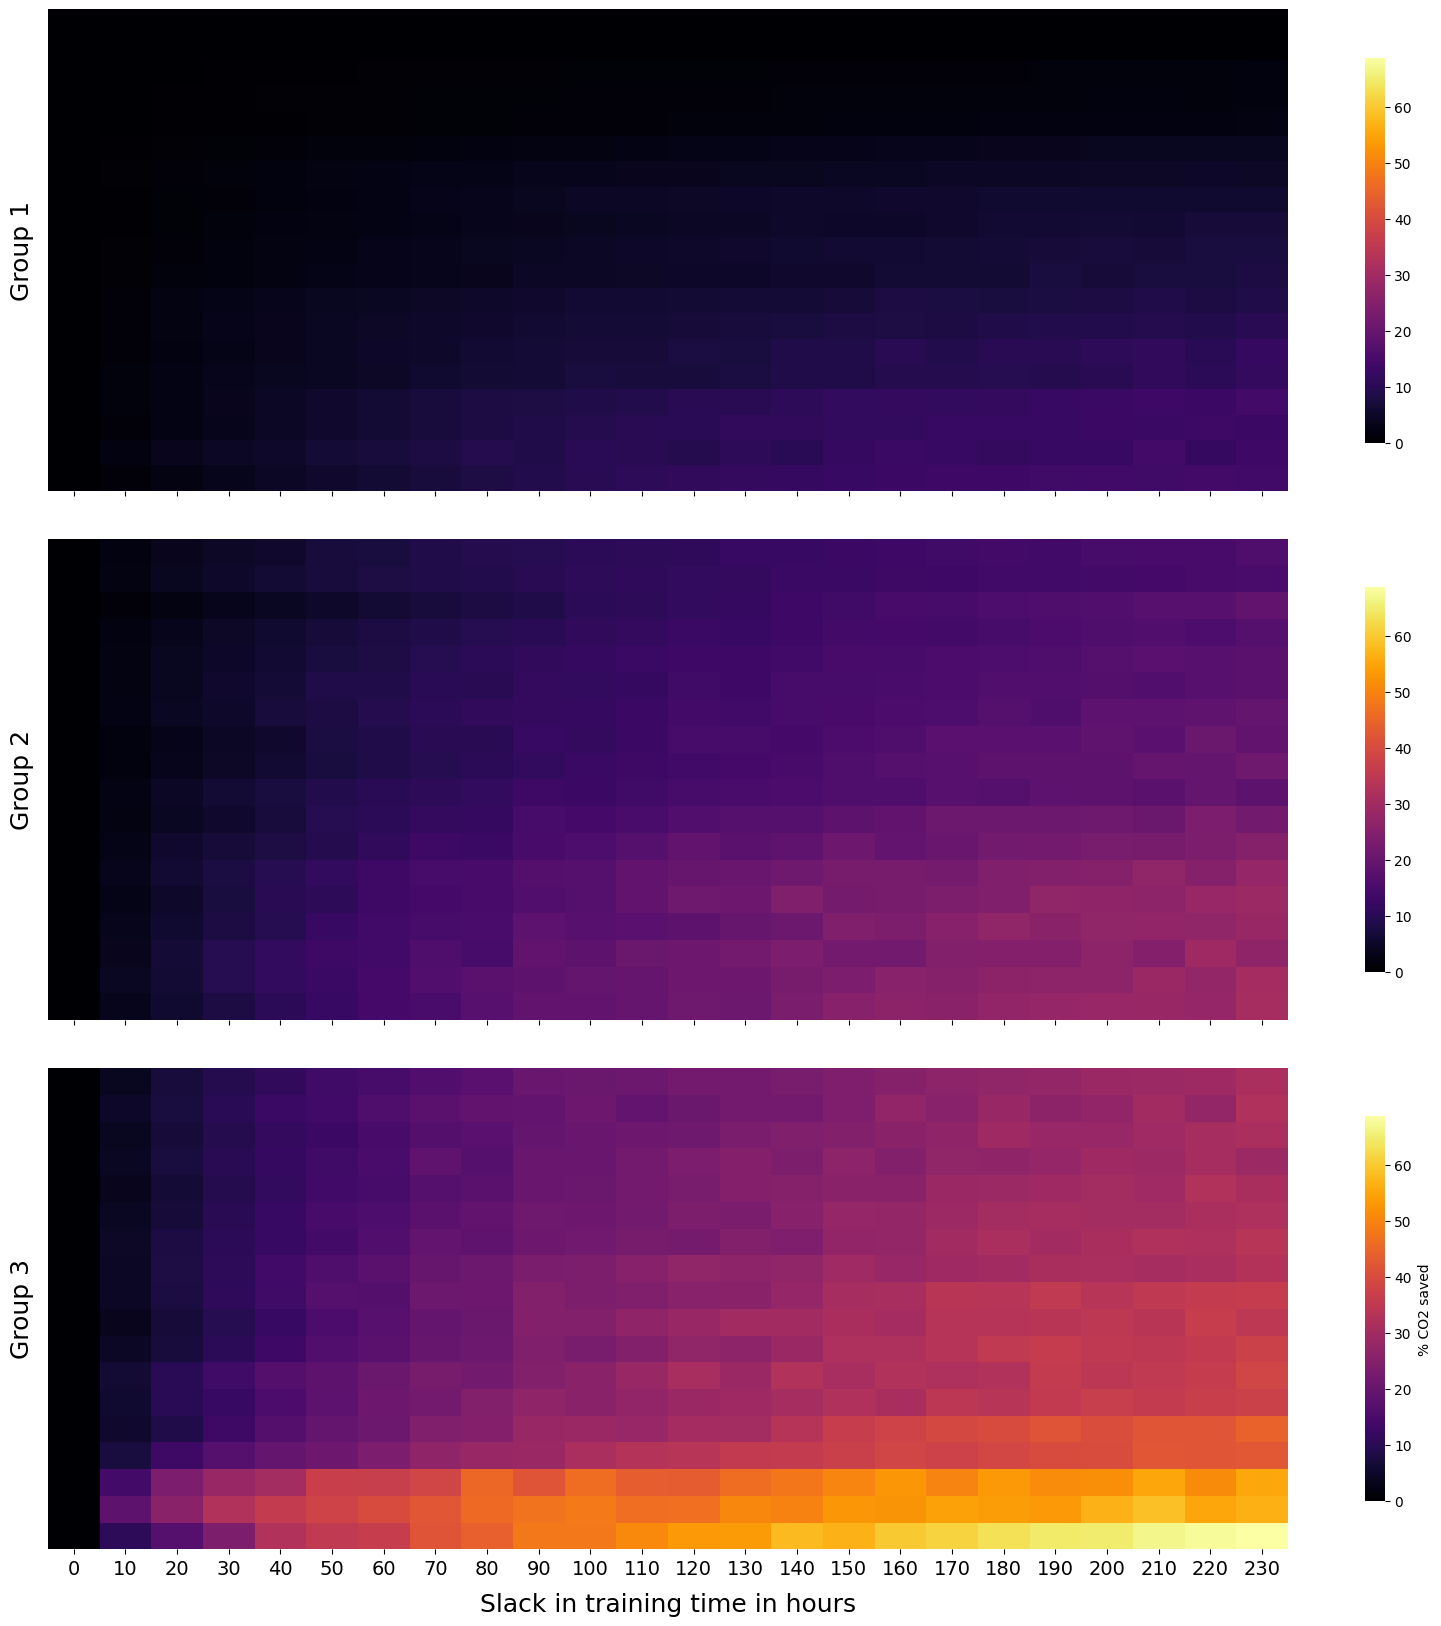

In [21]:
# Rank countries based on CO₂ savings
ranked_countries = tmp.mean().sort_values().index.values

# Define number of groups
num_groups = 3  # High, Medium, Low CO₂ savings
group_labels = ["Group 1", "Group 2", "Group 3"]

# Split into 3 equal-sized groups
group_sizes = np.array_split(ranked_countries, num_groups)

# Create heatmaps for each group
fig, axes = plt.subplots(num_groups, 1, figsize=(20, 20), sharex=True)

for i, (ax, group, label) in enumerate(zip(axes, group_sizes, group_labels)):
    # Extract data for the group
    group_data = tmp[group].T * 100
    
    # Plot heatmap
    sns.heatmap(group_data, cmap='inferno', ax=ax, cbar_kws={'label': '% CO2 saved' if i == 2 else "", 'shrink': 0.8},
                vmin=tmp.min().min() * 100, vmax=tmp.max().max() * 100, xticklabels=True if i == 2 else False,
                yticklabels=False)  # Hide country labels

    # Label each group
    ax.set_ylabel(label, fontsize=18, labelpad=10)

# Global x-label
axes[-1].set_xlabel("Slack in training time in hours", fontsize=18, labelpad=10)
axes[-1].tick_params(axis='x', labelsize=14)

# Adjust spacing between heatmaps
plt.subplots_adjust(hspace=0.1)  # Adjust gap between subplots

# Save and show
plt.savefig("../../stacked_grouped_slack_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
group_sizes

[array(['Hong Kong_HK', 'Australia_AU-NT', 'India_IN-EA', 'India_IN-WE',
        'Singapore_SG', 'Philippines_PH', 'South Africa_ZA', 'Israel_IL',
        'South Korea_KR', 'Taiwan_TW', 'India_IN-NE', 'Serbia_RS',
        'Bulgaria_BG', 'Czechia_CZ', 'Turkey_TR', 'Poland_PL',
        'India_IN-SO', 'Peru_PE', 'India_IN-NO'], dtype=object),
 array(['Romania_RO', 'Brazil_BR', 'Japan_JP', 'Hungary_HU', 'Slovakia_SK',
        'Croatia_HR', 'Panama_PA', 'Australia_AU-QLD', 'Cyprus_CY',
        'Australia_AU-VIC', 'Australia_AU-NSW', 'Slovenia_SI',
        'Austria_AT', 'Finland_FI', 'France_FR', 'New Zealand_NZ',
        'Estonia_EE', 'Germany_DE'], dtype=object),
 array(['Greece_GR', 'Latvia_LV', 'Spain_ES', 'Nicaragua_NI',
        'Australia_AU-WA', 'Belgium_BE', 'Portugal_PT', 'Netherlands_NL',
        'Ireland_IE', 'Chile_CL-SEN', 'Great Britain_GB', 'Lithuania_LT',
        'Denmark_DK', 'Northern Ireland_GB-NIR', 'Switzerland_CH',
        'Norway_NO', 'Sweden_SE-SE3', 'Canada_CA-ON'], 

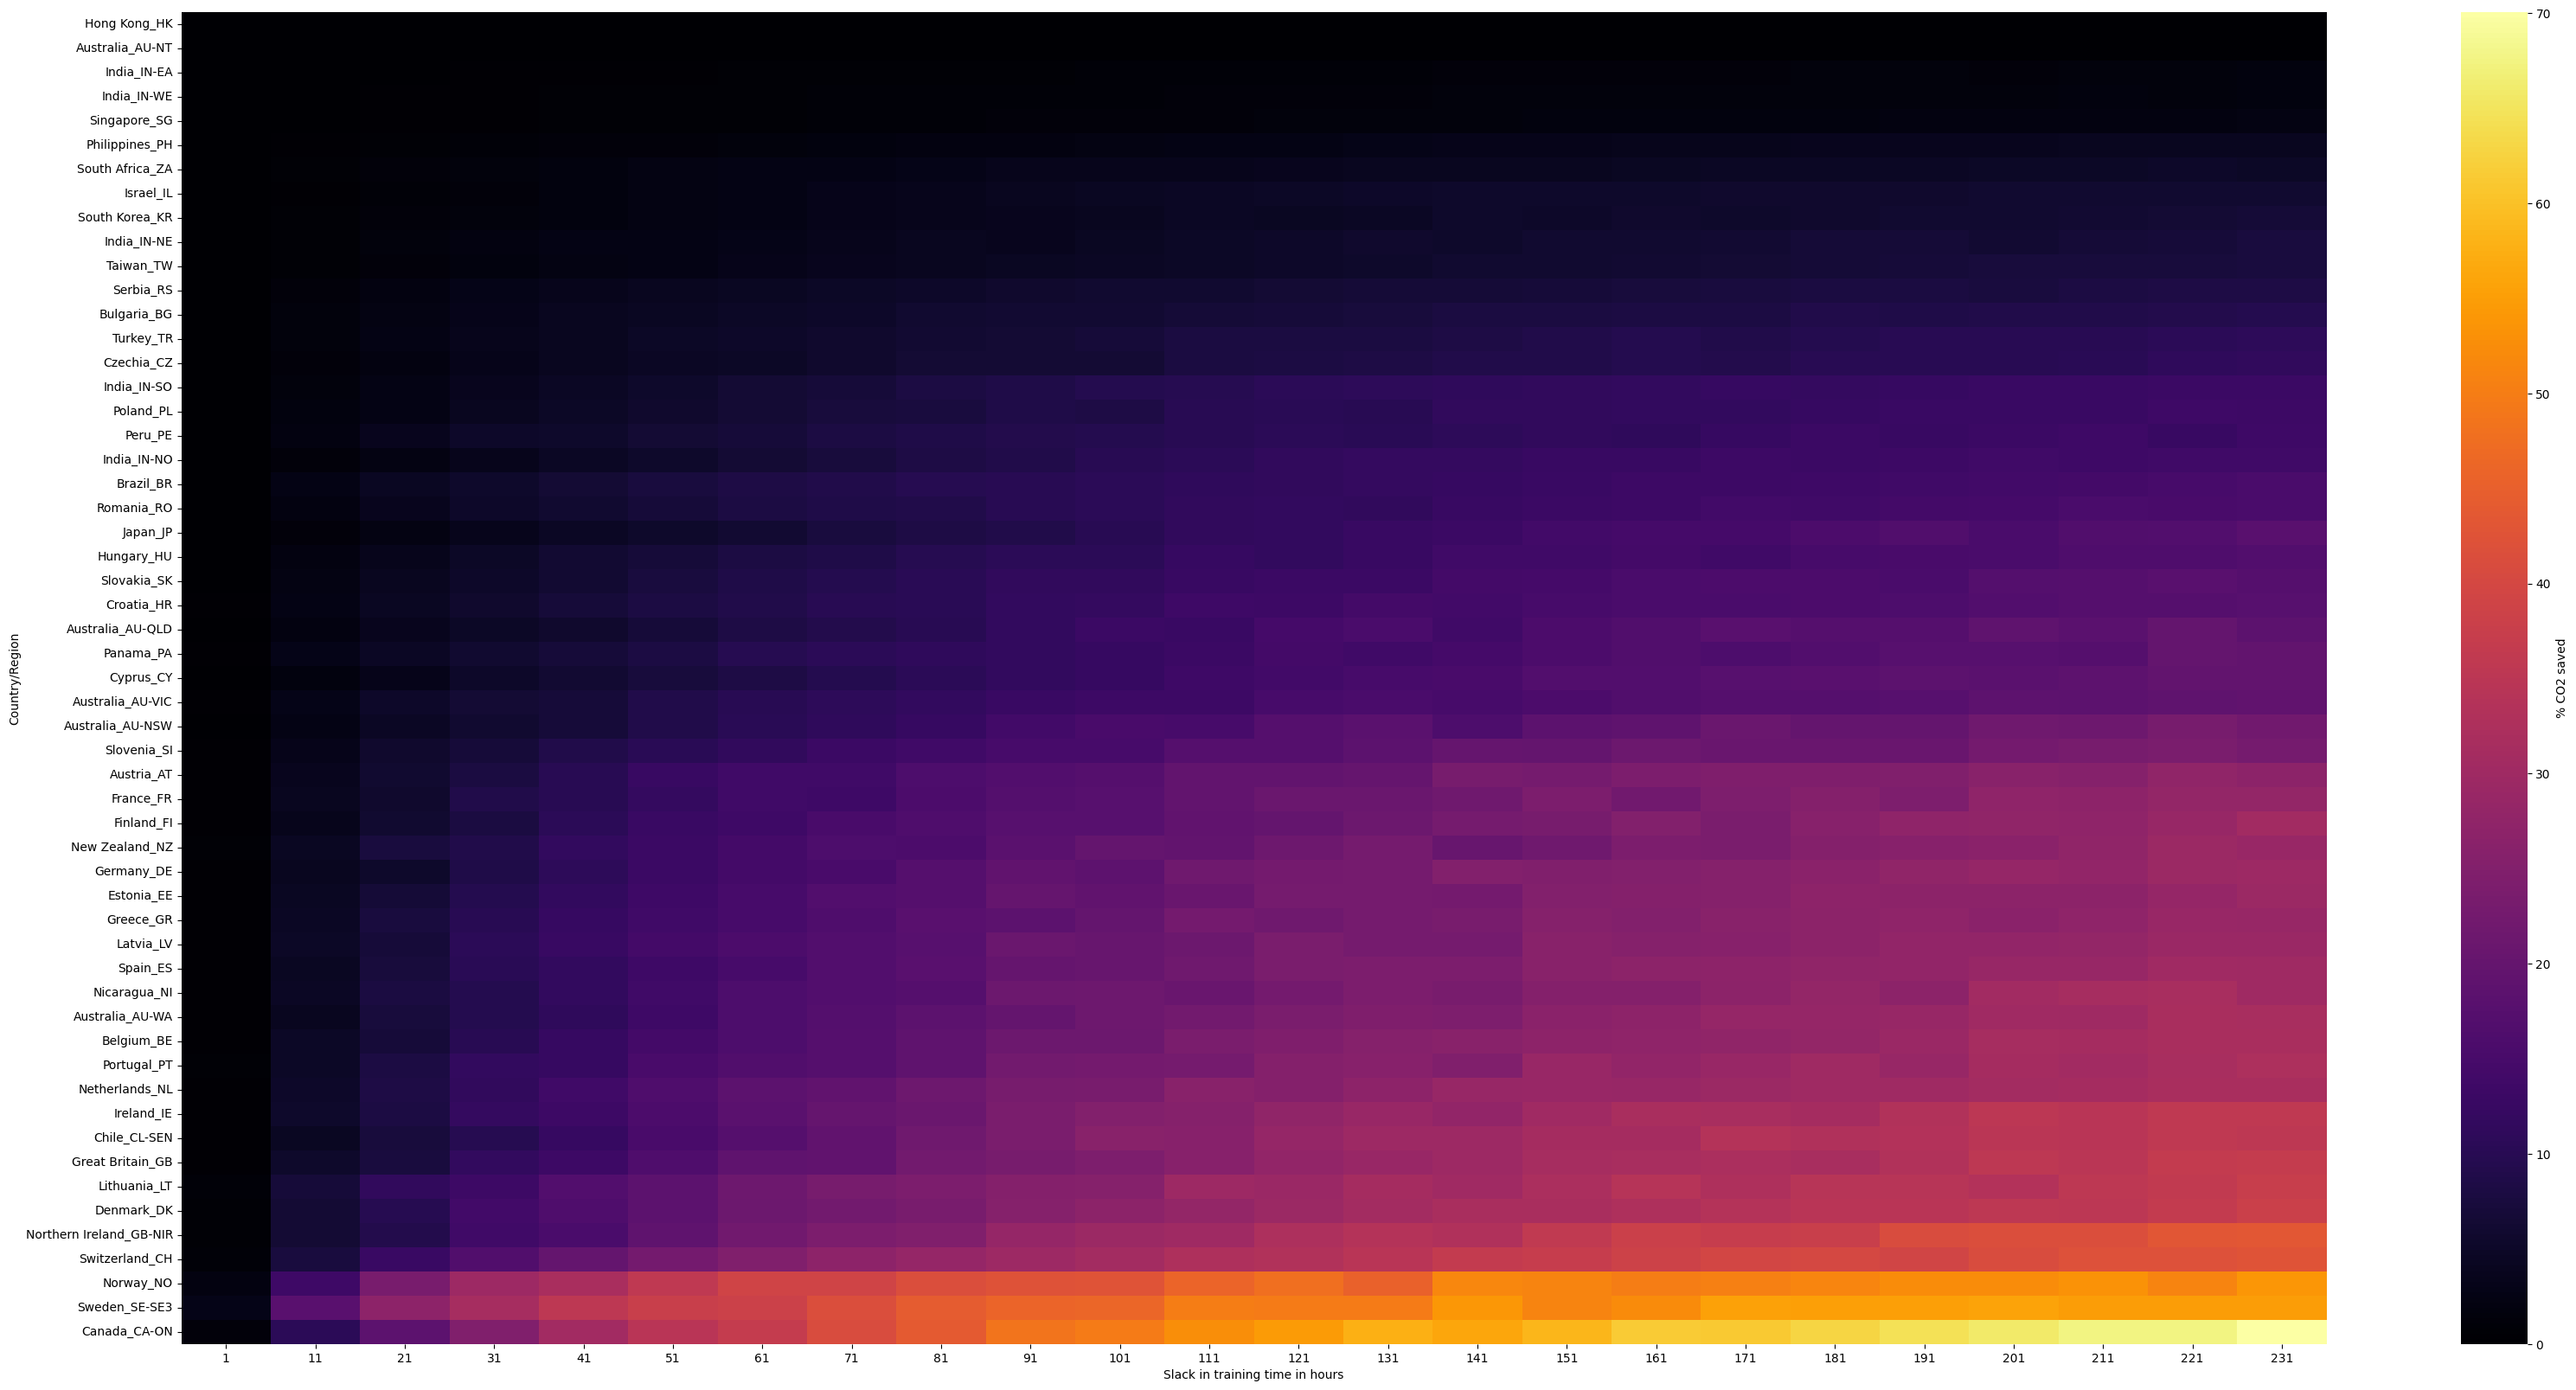

In [31]:
ranked_countries = tmp.mean().sort_values().index.values
fig, ax = plt.subplots(figsize=(40,20)) 
# Multiply values by 100, and set the color bar range based on the scaled values
scaled_data = tmp[ranked_countries].T * 100
sns.heatmap(scaled_data, cmap='inferno', ax=ax, cbar_kws={'label': '% CO2 saved'}, vmin=scaled_data.min().min(), vmax=scaled_data.max().max())
ax.set_xlabel("Slack in training time in hours")
ax.set_ylabel("Country/Region")
plt.savefig("../../slack_analysis.png")
plt.show()

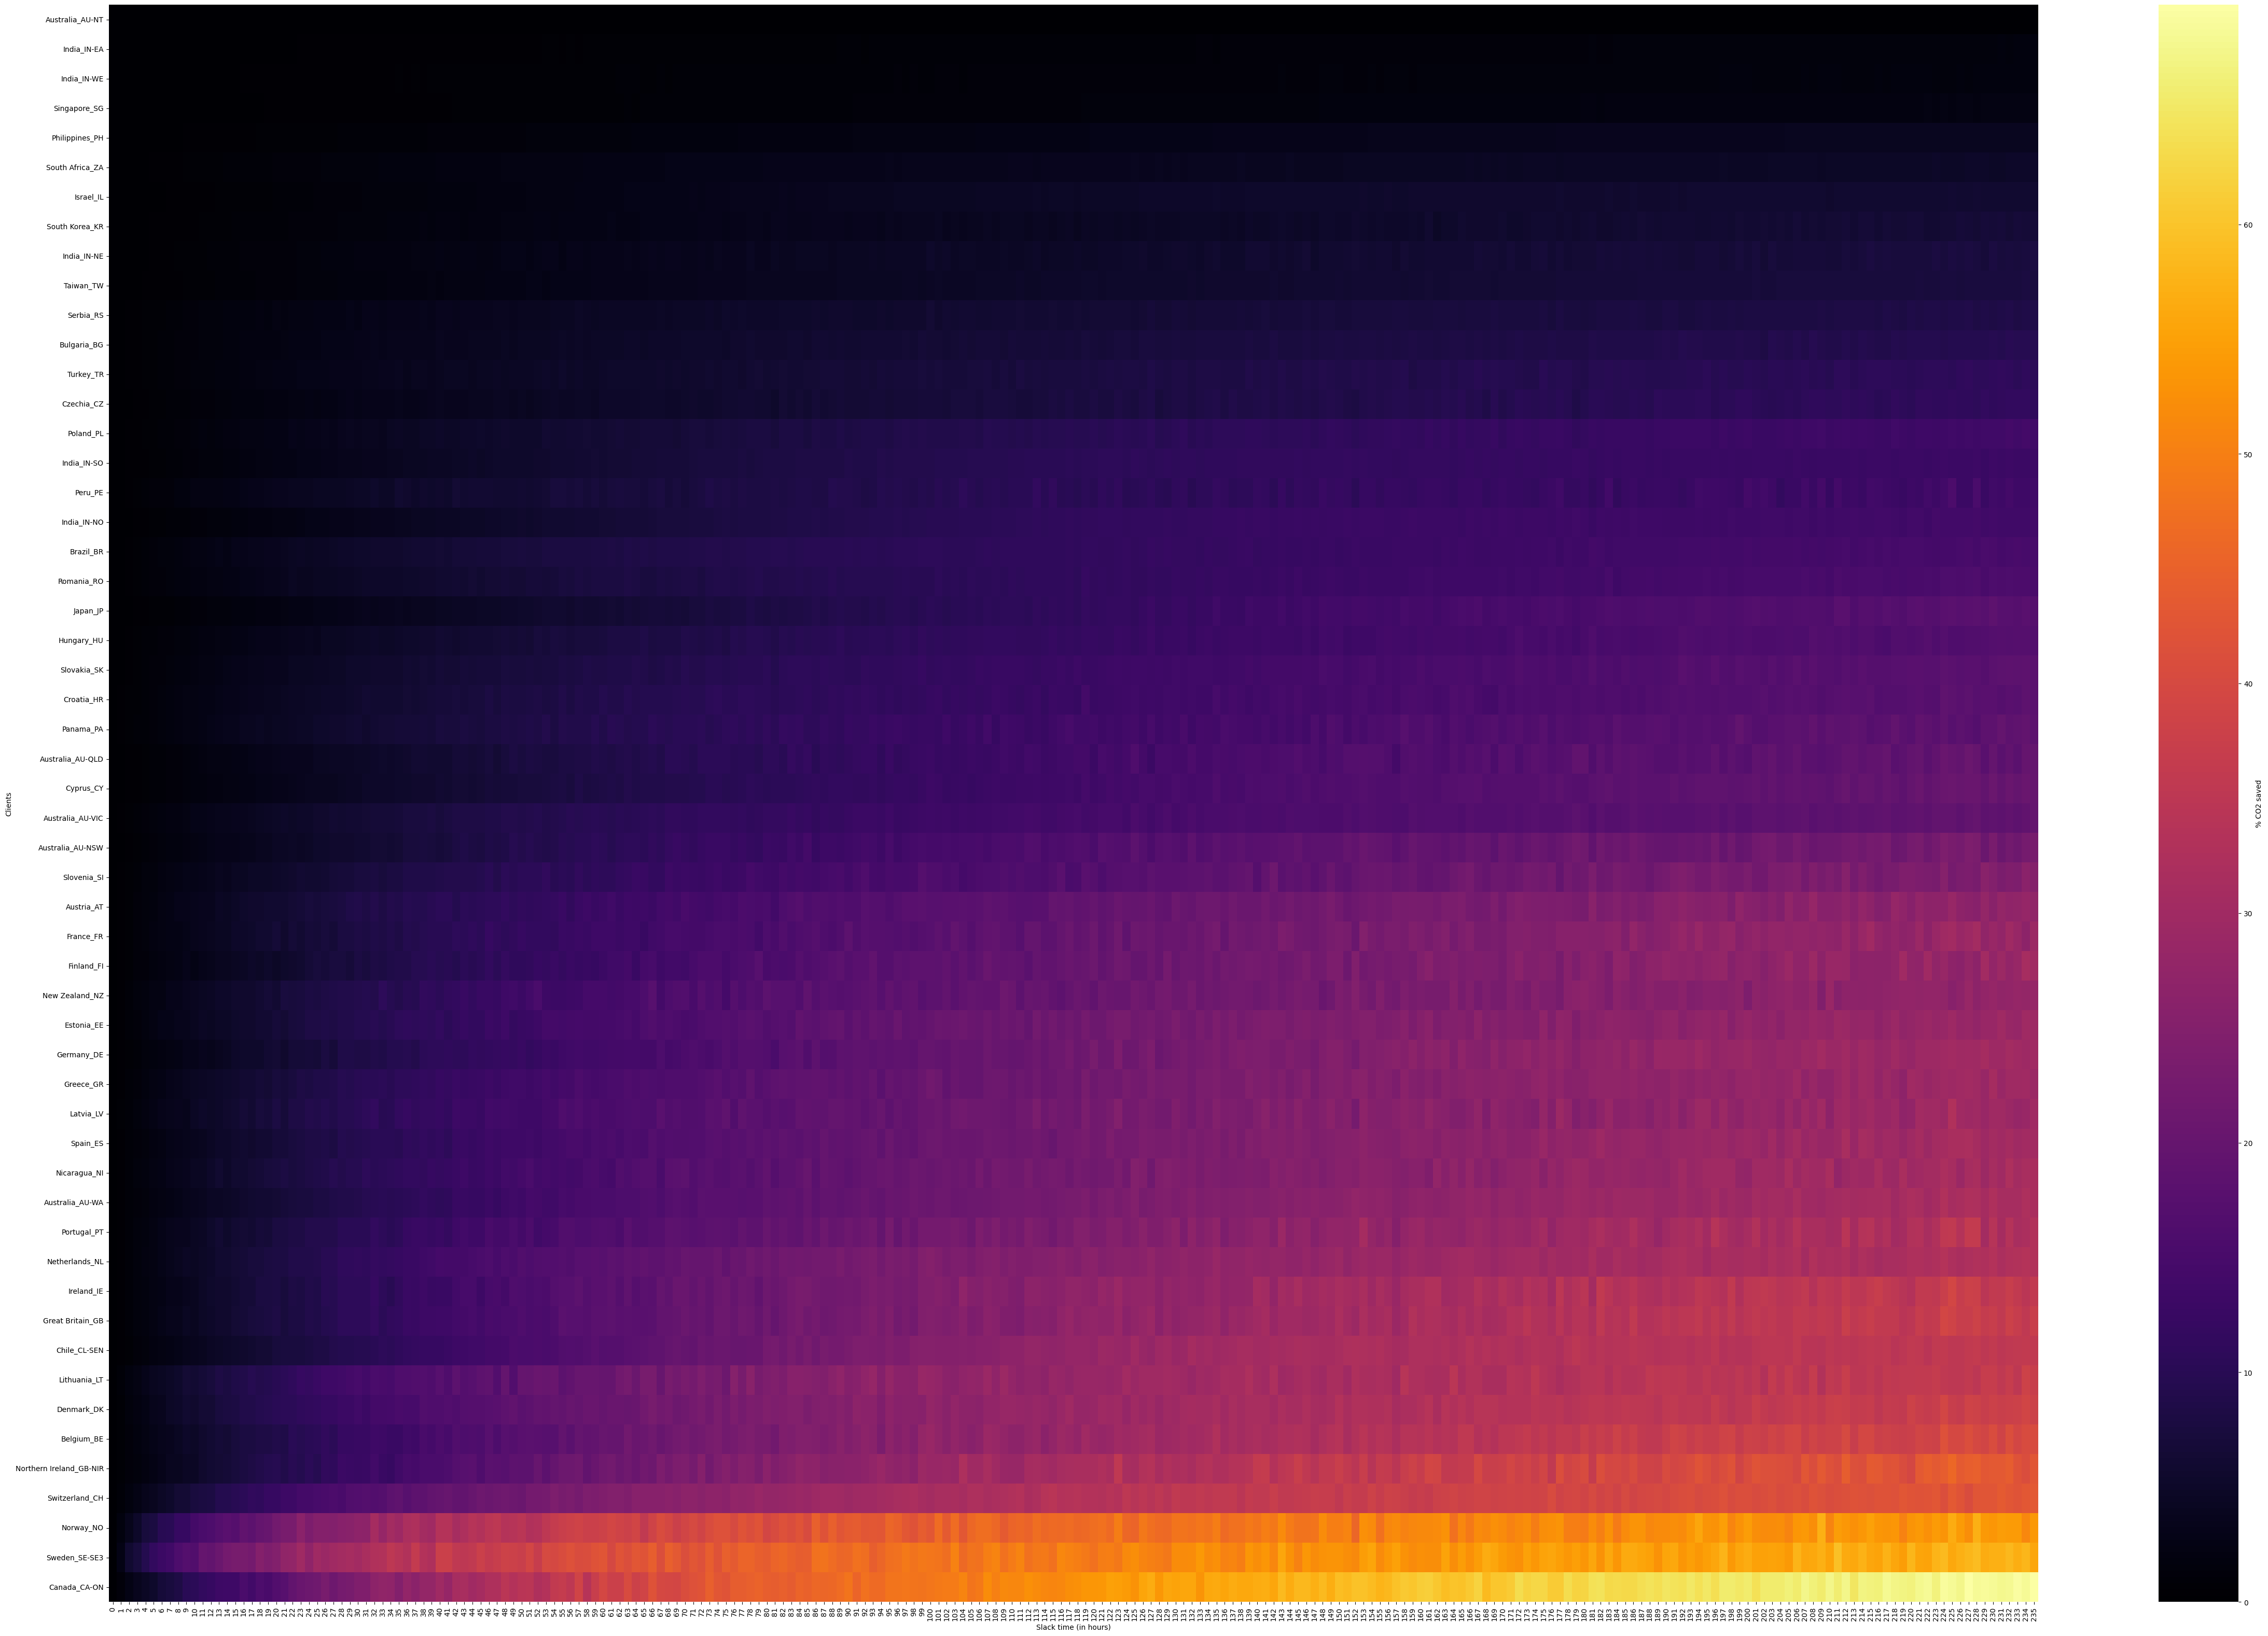

In [30]:
ranked_countries = tmp.mean().sort_values().index.values
fig, ax = plt.subplots(figsize=(60, 40)) 

# Multiply values by 100, and set the color bar range based on the scaled values
scaled_data = tmp[ranked_countries].T * 100
sns.heatmap(scaled_data, cmap='inferno', ax=ax, cbar_kws={'label': '% CO2 saved'}, 
            vmin=scaled_data.min().min(), vmax=scaled_data.max().max())

ax.set_xlabel("Slack time (in hours)")
ax.set_ylabel("Clients")

# Rotate y-axis labels for better readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')

plt.show()
